## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## loading dataset and quick glances

In [2]:
tot_data=pd.read_csv(r"C:\Users\hrish\Projects\ML_projects_to_learn\customer_churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

## splitting the data

In [227]:
from sklearn.model_selection import train_test_split
y=tot_data[['Churn','customerID']]
X=tot_data.drop(columns=['Churn'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y['Churn'], random_state=42)

In [4]:
data=X_train.copy()

In [5]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6661,3704-IEAXF,Female,0,Yes,Yes,72,No,No phone service,DSL,No,Yes,No,Yes,Yes,Yes,Two year,No,Credit card (automatic),53.65,3784
4811,5175-AOBHI,Female,0,No,No,4,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,46.00,193.6
2193,6922-NCEDI,Male,0,No,Yes,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,21.20,1238.65
1904,3143-ILDAL,Male,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,94.45,5124.6
6667,0872-NXJYS,Female,0,No,No,9,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,79.55,723.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4250,0565-JUPYD,Male,0,No,No,63,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,No,One year,No,Credit card (automatic),104.50,6590.8
1488,8695-WDYEA,Male,0,No,No,1,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,51.25,51.25
6303,6308-CQRBU,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.7
2710,3594-BDSOA,Female,0,Yes,No,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.8


In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 5282 entries, 6661 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5282 non-null   str    
 1   gender            5282 non-null   str    
 2   SeniorCitizen     5282 non-null   int64  
 3   Partner           5282 non-null   str    
 4   Dependents        5282 non-null   str    
 5   tenure            5282 non-null   int64  
 6   PhoneService      5282 non-null   str    
 7   MultipleLines     5282 non-null   str    
 8   InternetService   5282 non-null   str    
 9   OnlineSecurity    5282 non-null   str    
 10  OnlineBackup      5282 non-null   str    
 11  DeviceProtection  5282 non-null   str    
 12  TechSupport       5282 non-null   str    
 13  StreamingTV       5282 non-null   str    
 14  StreamingMovies   5282 non-null   str    
 15  Contract          5282 non-null   str    
 16  PaperlessBilling  5282 non-null   str    
 17  PaymentM

In [7]:
for col in data.columns:
    if(len(data[col].unique())<5):
        print(f"{col}: {data[col].unique()}")

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen: [0 1]
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'No', 'Fiber optic']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'No internet service', 'Yes']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'No internet service', 'Yes']
Length: 3, dtype: str
TechSupport: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Contract: <StringArray>
['Two year'

In [8]:
(data['TotalCharges']==' ').sum()

np.int64(8)

In [9]:
data[data['TotalCharges']==' '][['MonthlyCharges','tenure']]

,MonthlyCharges,tenure
6670,73.35,0
3826,25.35,0
4380,20.00,0
488,52.55,0
1082,25.75,0
1340,56.05,0
6754,61.90,0
3331,19.85,0


### doing the above using transformers and pipelines

In [10]:
def true_conv(n):
    return (n=='Yes').astype(int)
def clean_total_charges(X):
    return X.replace(' ', 0).astype(float)
def gen_func(n):
    return (n=='Male').astype(int)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
enc = OneHotEncoder(sparse_output=False) 

In [11]:
bin_at=list(data.columns[9:15])+list(data.columns[3:5])+['PhoneService','MultipleLines','PaperlessBilling']
ohe_at=['InternetService','Contract','PaymentMethod']
yes_no_transformer = FunctionTransformer(true_conv, feature_names_out='one-to-one')
charges_transformer = FunctionTransformer(clean_total_charges, feature_names_out='one-to-one')
gender_transformer = FunctionTransformer(gen_func, feature_names_out='one-to-one')
preprocessing = ColumnTransformer([("yes_to_1", yes_no_transformer, bin_at),("ohe", enc, ohe_at),('tot_char',charges_transformer,['TotalCharges']),('ohe_gen',gender_transformer,['gender'])],remainder='passthrough',verbose_feature_names_out=False)
preprocessing.set_output(transform="pandas")

,transformers,"[('yes_to_1', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,func,<function tru...00234D4F67B00>
,inverse_func,None
,validate,False


In [12]:
processed_data = preprocessing.fit_transform(data)

In [13]:
y_train['Churn'] = (y_train['Churn'] == 'Yes').astype(int)

In [14]:
processed_data

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Partner,Dependents,PhoneService,MultipleLines,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalCharges,gender,customerID,SeniorCitizen,tenure,MonthlyCharges
6661,0,1,0,1,1,1,1,1,0,0,...,0.0,1.0,0.0,0.0,3784.00,0,3704-IEAXF,0,72,53.65
4811,0,0,0,0,0,0,0,0,1,0,...,0.0,0.0,0.0,1.0,193.60,0,5175-AOBHI,0,4,46.00
2193,0,0,0,0,0,0,0,1,1,0,...,0.0,0.0,0.0,1.0,1238.65,1,6922-NCEDI,0,56,21.20
1904,0,1,0,1,0,1,0,0,1,1,...,0.0,0.0,1.0,0.0,5124.60,1,3143-ILDAL,0,56,94.45
6667,0,0,0,0,0,1,0,0,1,0,...,0.0,0.0,1.0,0.0,723.40,0,0872-NXJYS,0,9,79.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4250,1,1,1,1,1,0,0,0,1,1,...,0.0,1.0,0.0,0.0,6590.80,1,0565-JUPYD,0,63,104.50
1488,1,0,0,0,0,0,0,0,1,0,...,0.0,0.0,0.0,1.0,51.25,1,8695-WDYEA,0,1,51.25
6303,0,1,1,1,1,1,1,0,1,1,...,0.0,0.0,1.0,0.0,7707.70,0,6308-CQRBU,0,71,109.25
2710,0,0,0,0,0,0,1,0,1,0,...,0.0,1.0,0.0,0.0,482.80,0,3594-BDSOA,0,24,20.40


In [15]:
processed_data.info()

<class 'pandas.DataFrame'>
Index: 5282 entries, 6661 to 5639
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   OnlineSecurity                           5282 non-null   int64  
 1   OnlineBackup                             5282 non-null   int64  
 2   DeviceProtection                         5282 non-null   int64  
 3   TechSupport                              5282 non-null   int64  
 4   StreamingTV                              5282 non-null   int64  
 5   StreamingMovies                          5282 non-null   int64  
 6   Partner                                  5282 non-null   int64  
 7   Dependents                               5282 non-null   int64  
 8   PhoneService                             5282 non-null   int64  
 9   MultipleLines                            5282 non-null   int64  
 10  PaperlessBilling                         5282 non-null   int6

In [16]:
processed_data[['tenure','MonthlyCharges','TotalCharges',]].describe()

,tenure,MonthlyCharges,TotalCharges
count,5282.000000,5282.000000,5282.000000
mean,32.362931,64.856626,2292.083538
std,24.627623,30.171934,2285.168876
min,0.000000,18.400000,0.000000
25%,9.000000,35.450000,391.062500
50%,29.000000,70.500000,1385.300000
75%,55.750000,89.987500,3841.637500
max,72.000000,118.750000,8684.800000


In [17]:
y_train['Churn'].value_counts()

Churn
0    3880
1    1402
Name: count, dtype: int64

## Data processing and data visualisation

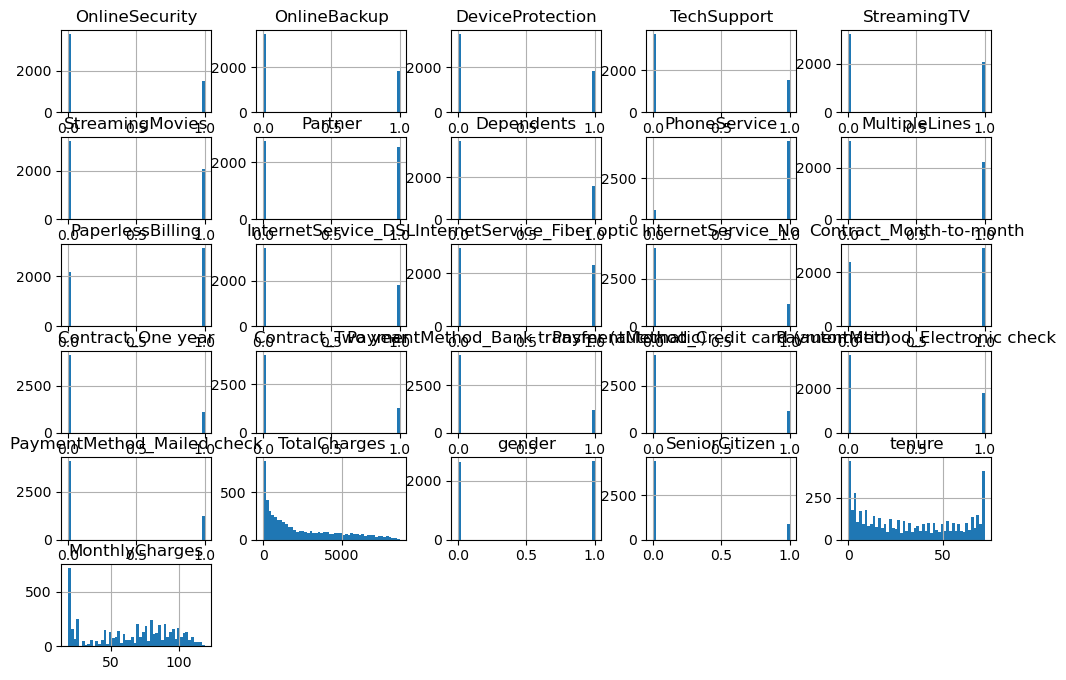

In [18]:
processed_data.hist(bins=50,figsize=(12,8))
plt.show()

In [19]:
data_vis=pd.merge(processed_data, y_train, on="customerID")

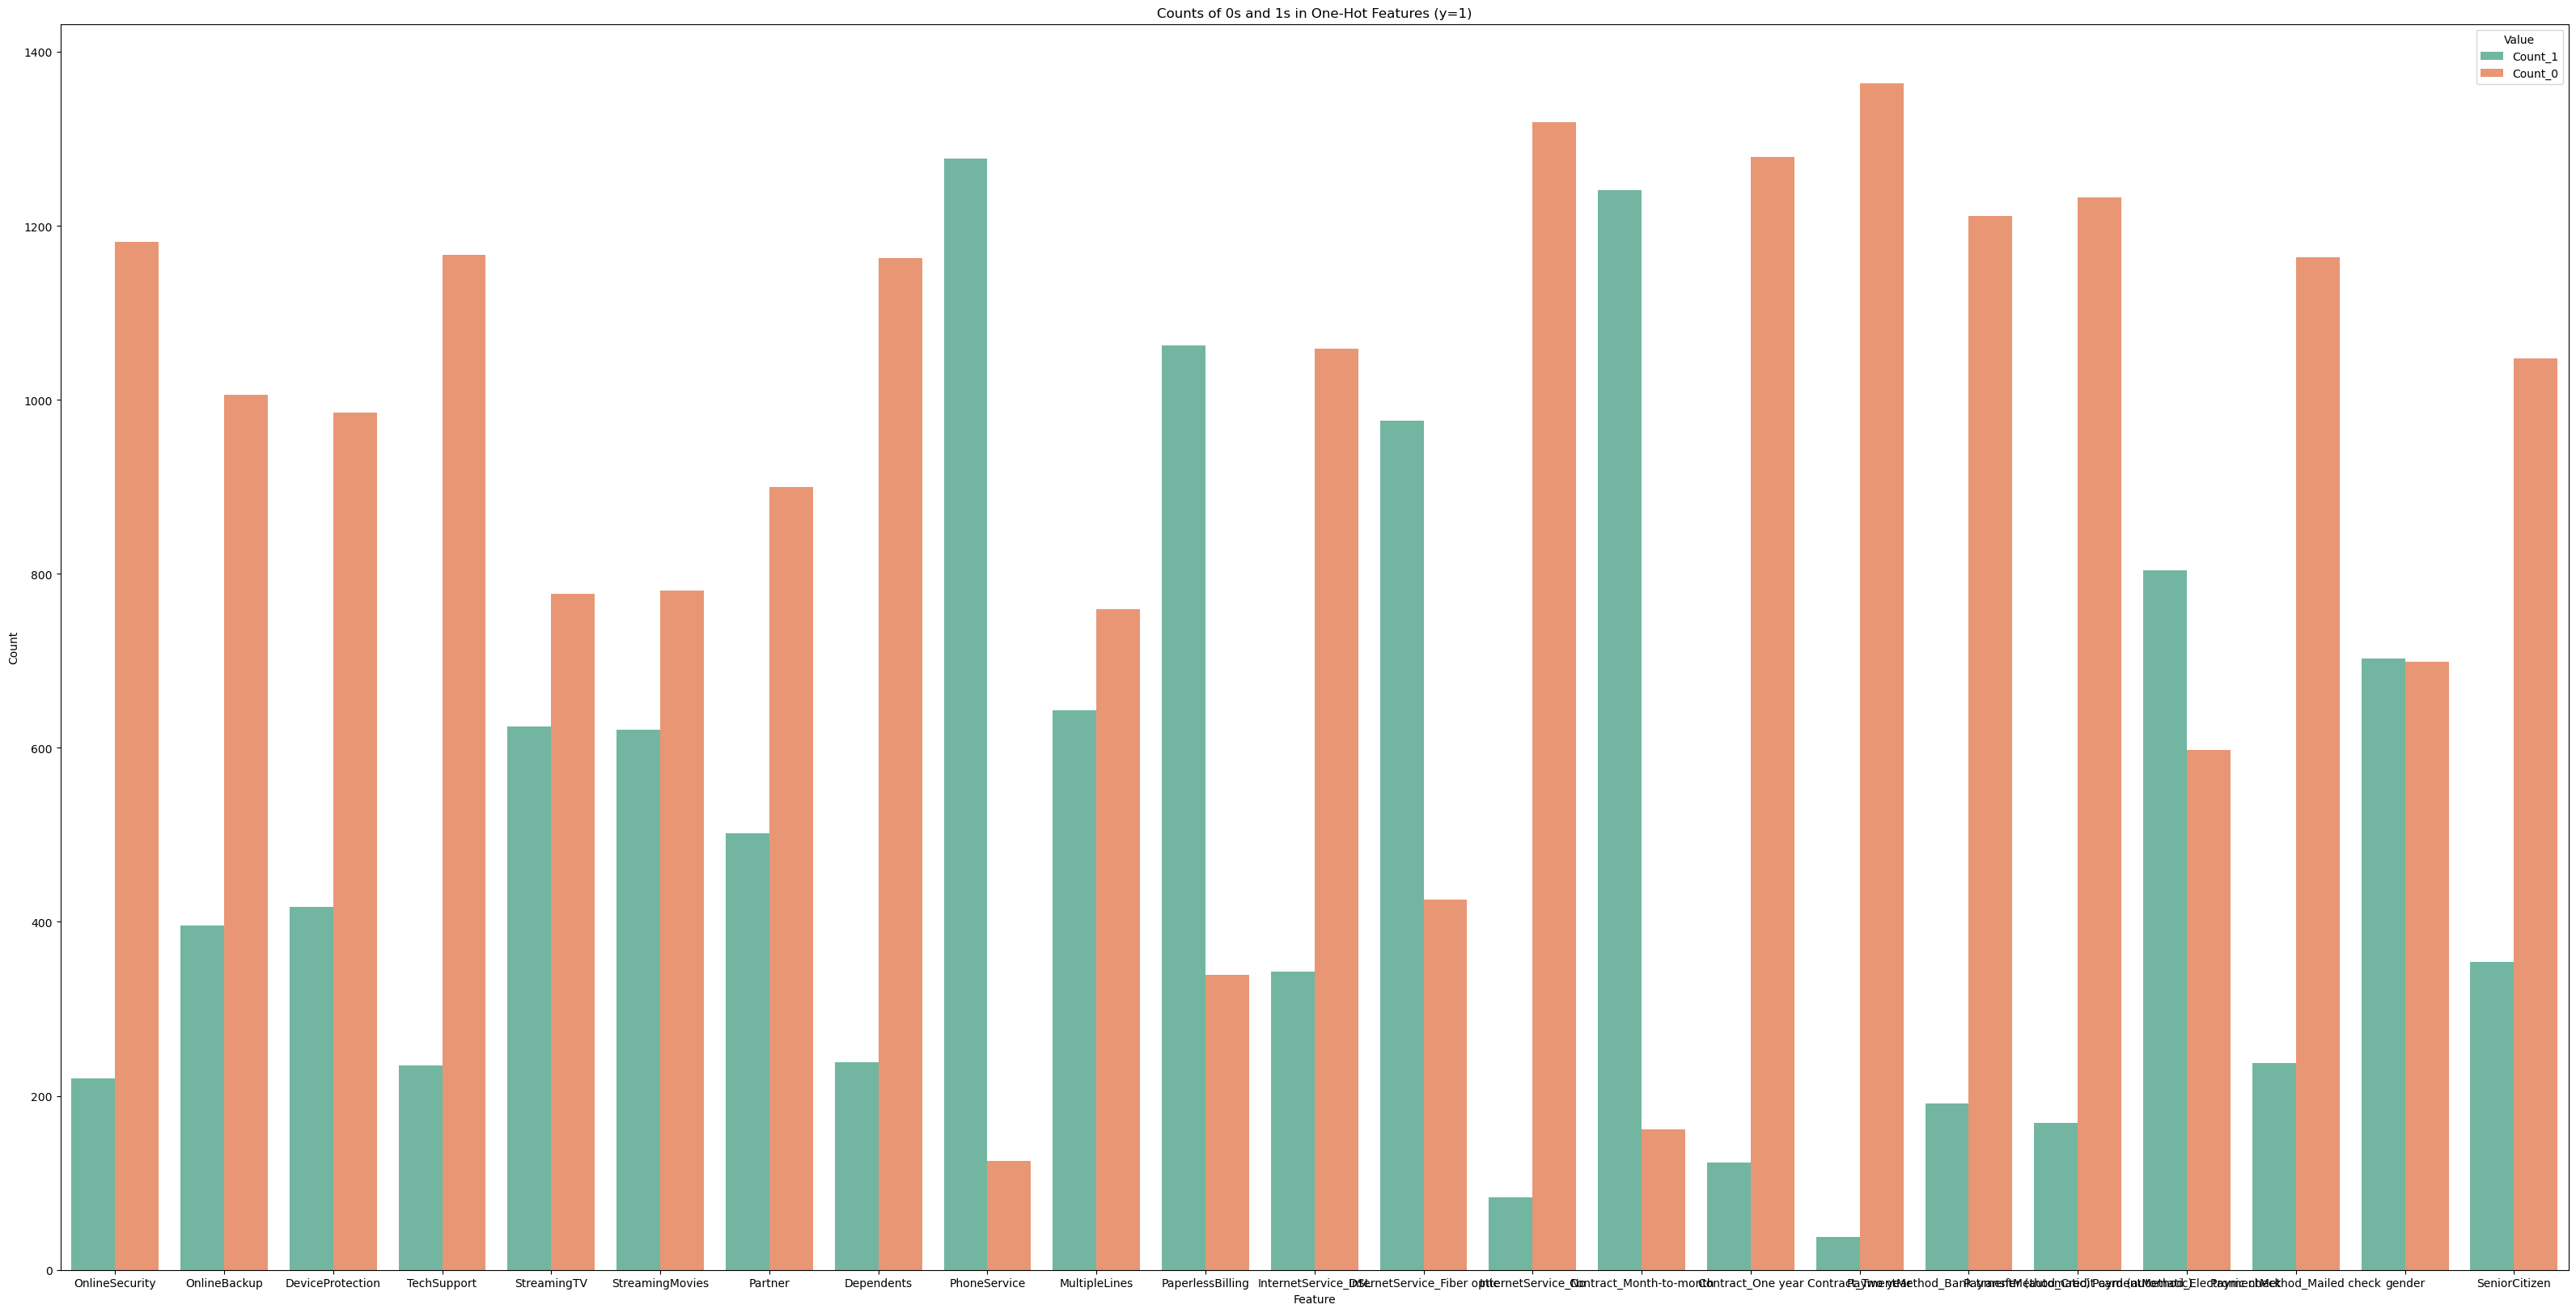

In [20]:
one_hot_cols = list(data_vis.columns[0:21])+['gender','SeniorCitizen']
df_y1 = data_vis[data_vis['Churn'] == 1]
counts = {}
for col in one_hot_cols:
    counts[col] = df_y1[col].value_counts().reindex([1,0], fill_value=0)
counts_df = pd.DataFrame(counts).T.reset_index()
counts_df.columns = ['Feature', 'Count_1', 'Count_0']

plot_df = counts_df.melt(id_vars='Feature', value_vars=['Count_1','Count_0'],
                         var_name='Value', value_name='Count')

plt.figure(figsize=(40,20))
sns.barplot(x='Feature', y='Count', hue='Value', data=plot_df, palette='Set2')
plt.title("Counts of 0s and 1s in One-Hot Features (y=1)")
plt.show()


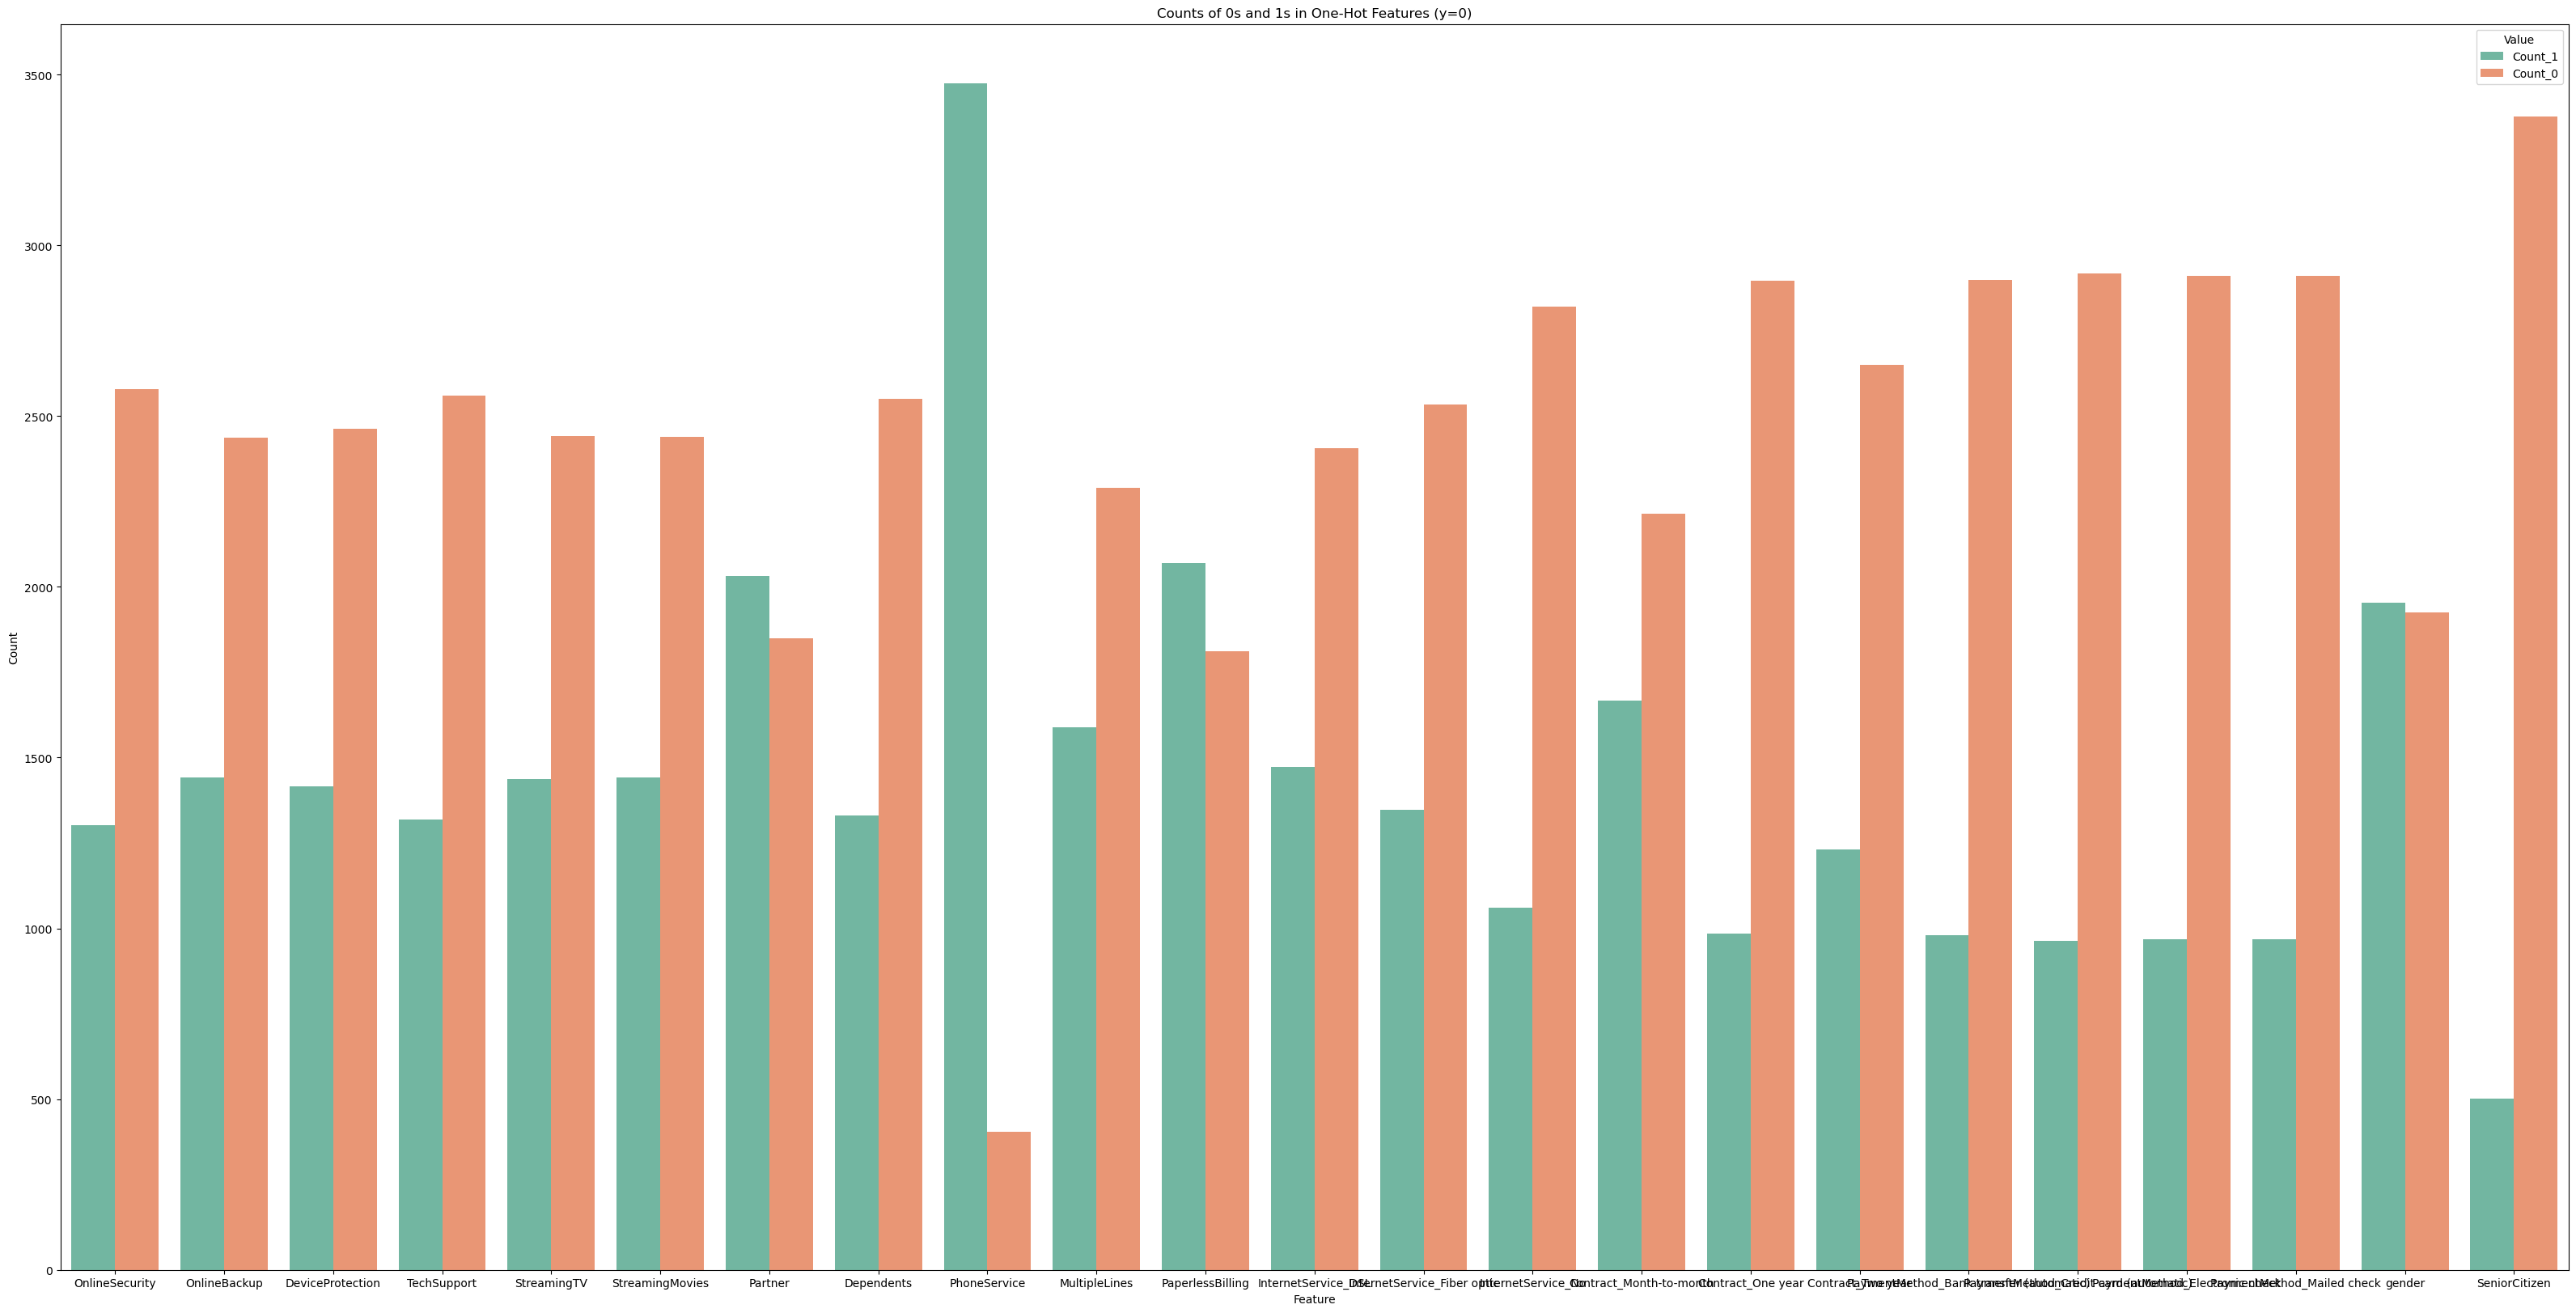

In [21]:
one_hot_cols = list(data_vis.columns[0:21])+['gender','SeniorCitizen']
df_y1 = data_vis[data_vis['Churn'] == 0]
counts = {}
for col in one_hot_cols:
    counts[col] = df_y1[col].value_counts().reindex([1,0], fill_value=0)
counts_df = pd.DataFrame(counts).T.reset_index()
counts_df.columns = ['Feature', 'Count_1', 'Count_0']

plot_df = counts_df.melt(id_vars='Feature', value_vars=['Count_1','Count_0'],
                         var_name='Value', value_name='Count')

plt.figure(figsize=(40,20))
sns.barplot(x='Feature', y='Count', hue='Value', data=plot_df, palette='Set2')
plt.title("Counts of 0s and 1s in One-Hot Features (y=0)")
plt.show()

<Axes: >

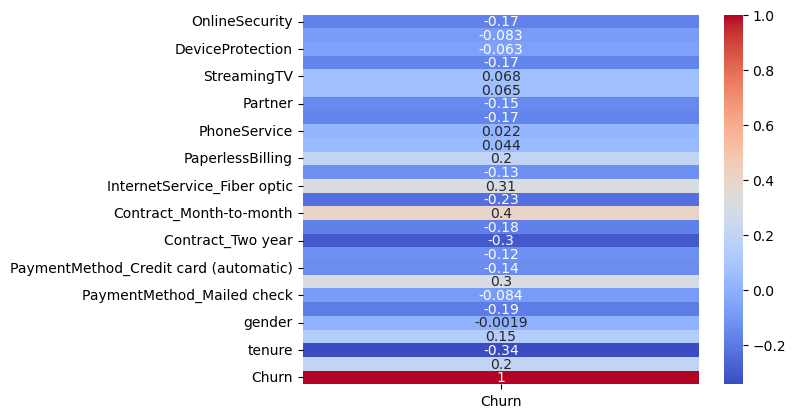

In [22]:
corr = data_vis.drop(columns="customerID").corr()[['Churn']] 
sns.heatmap(corr, annot=True, cmap="coolwarm")

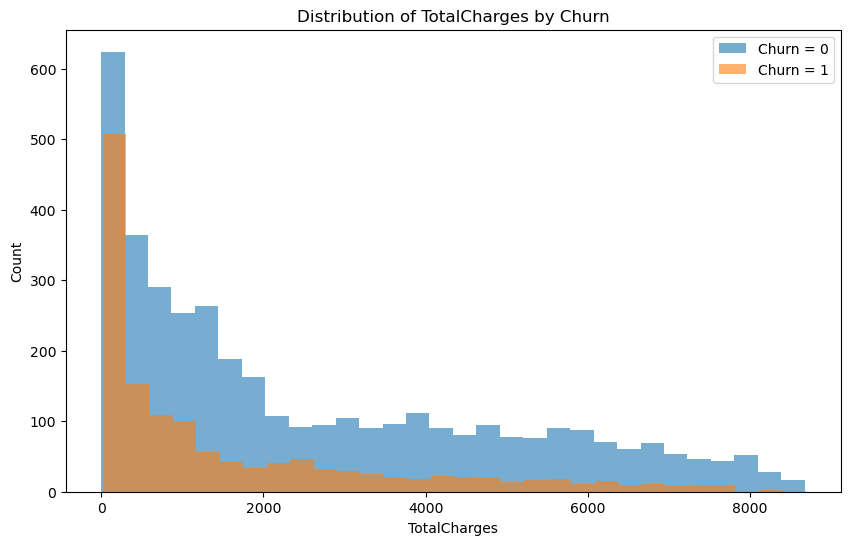

In [23]:
plt.figure(figsize=(10,6))

# Histogram for churn = 0
plt.hist(data_vis[data_vis['Churn']==0]['TotalCharges'], 
         bins=30, alpha=0.6, label='Churn = 0')

# Histogram for churn = 1
plt.hist(data_vis[data_vis['Churn']==1]['TotalCharges'], 
         bins=30, alpha=0.6, label='Churn = 1')

plt.xlabel('TotalCharges')
plt.ylabel('Count')
plt.title('Distribution of TotalCharges by Churn')
plt.legend()
plt.show()


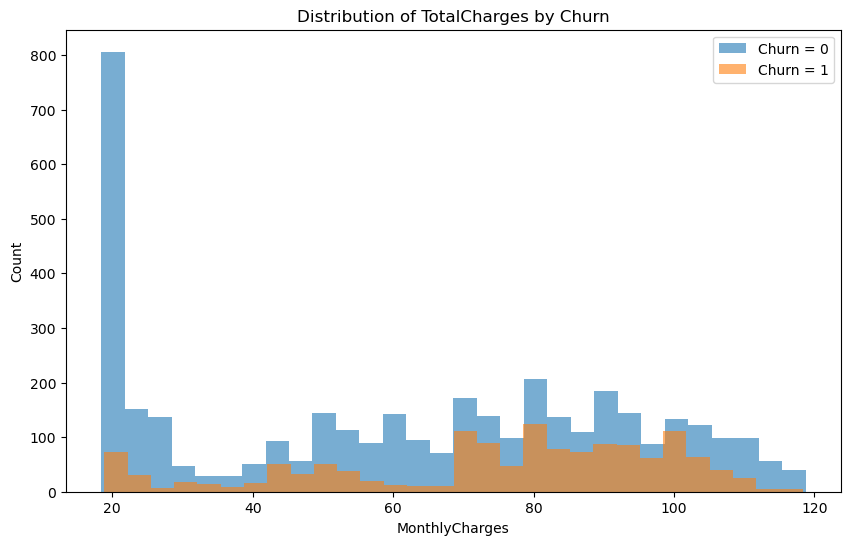

In [24]:
plt.figure(figsize=(10,6))

# Histogram for churn = 0
plt.hist(data_vis[data_vis['Churn']==0]['MonthlyCharges'], 
         bins=30, alpha=0.6, label='Churn = 0')

# Histogram for churn = 1
plt.hist(data_vis[data_vis['Churn']==1]['MonthlyCharges'], 
         bins=30, alpha=0.6, label='Churn = 1')

plt.xlabel('MonthlyCharges')
plt.ylabel('Count')
plt.title('Distribution of TotalCharges by Churn')
plt.legend()
plt.show()


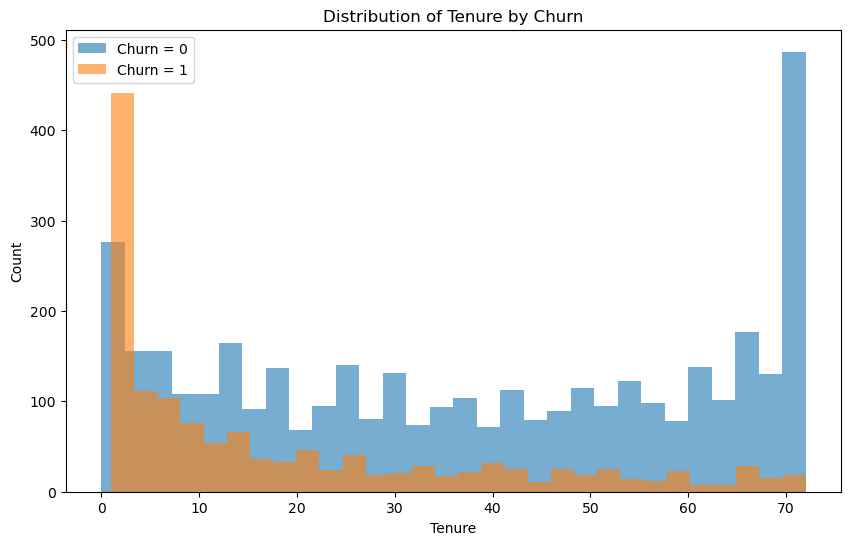

In [25]:
plt.figure(figsize=(10,6))

# Histogram for churn = 0
plt.hist(data_vis[data_vis['Churn']==0]['tenure'], 
         bins=30, alpha=0.6, label='Churn = 0')

# Histogram for churn = 1
plt.hist(data_vis[data_vis['Churn']==1]['tenure'], 
         bins=30, alpha=0.6, label='Churn = 1')

plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Distribution of Tenure by Churn')
plt.legend()
plt.show()


## feature transformation and feature scaling

In [26]:
from sklearn.preprocessing import FunctionTransformer
log_trans = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

In [27]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted,validate_data

class MedianRBFTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, gamma=0.1):
        self.gamma = gamma

    def fit(self, X, y=None):
        # Validates input, converts to array, and handles feature_names_in_
        X = validate_data(self, X=X, reset=True)
        
        # Calculate medians across rows (axis=0)
        # Shape becomes (n_features,) which broadcasts perfectly over X
        self.medians_ = np.median(X, axis=0) 
        return self

    def transform(self, X):
        # Ensure fit has been called
        check_is_fitted(self, 'medians_')
        
        # Validate input without overwriting fit attributes
        X = validate_data(self, X=X, reset=True)

        # Fully vectorized RBF calculation (No for-loops)
        transformed = np.exp(-self.gamma * (X - self.medians_) ** 2)
        
        return transformed

    def get_feature_names_out(self, input_features=None):
        """Allows sklearn to automatically format pandas outputs."""
        if input_features is None:
            input_features = getattr(self, "feature_names_in_", None)
        
        # Fallback if numpy array was passed without feature names
        if input_features is None:
            input_features = [f"x{i}" for i in range(self.medians_.shape[0])]
            
        return np.array([f"rbf_{name}" for name in input_features])

In [28]:
rb_col=['MonthlyCharges','tenure']
ftr_trs = ColumnTransformer([("rbf_kernel", MedianRBFTransformer(gamma=0.1), rb_col),("log", log_trans, ['TotalCharges'])],remainder='passthrough',verbose_feature_names_out=False)
ftr_trs.set_output(transform="pandas")

,transformers,"[('rbf_kernel', ...), ('log', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,gamma,0.1
,func,<ufunc 'log1p'>
,inverse_func,None


In [29]:
trs_data = ftr_trs.fit_transform(processed_data)

In [30]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
ftr_scl = ColumnTransformer([("scale_data", min_max_scaler, ['rbf_tenure','rbf_MonthlyCharges','TotalCharges'])],remainder='passthrough',verbose_feature_names_out=False)
ftr_scl.set_output(transform="pandas")

,transformers,"[('scale_data', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [31]:
scaled_data = ftr_scl.fit_transform(trs_data)

In [32]:
scaled_data

,rbf_tenure,rbf_MonthlyCharges,TotalCharges,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Partner,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,customerID,SeniorCitizen
6661,0.000000e+00,4.670921e-13,0.908413,0,1,0,1,1,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,3704-IEAXF,0
4811,7.187782e-28,8.540312e-27,0.581176,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,5175-AOBHI,0
2193,2.187420e-32,2.787151e-106,0.785339,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,6922-NCEDI,0
1904,2.187420e-32,1.226761e-25,0.941844,0,1,0,1,0,1,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,3143-ILDAL,0
6667,4.248354e-18,2.773445e-04,0.726102,0,0,0,0,0,1,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0872-NXJYS,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4250,6.245366e-51,6.245366e-51,0.969583,1,1,1,1,1,0,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0565-JUPYD,0
1488,8.939487e-35,8.066314e-17,0.436194,1,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,8695-WDYEA,0
6303,2.456773e-77,6.137185e-66,0.986842,0,1,1,1,1,1,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,6308-CQRBU,0
2710,8.208500e-02,9.809588e-110,0.681593,0,0,0,0,0,0,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,3594-BDSOA,0


## building my data pipeline

In [33]:
from sklearn.pipeline import Pipeline

master_preprocessor = Pipeline(steps=[
    ('step1_process', preprocessing),     
    ('step2_transform', ftr_trs), 
    ('step3_scale', ftr_scl)           
])

master_preprocessor.set_output(transform="pandas")

,steps,"[('step1_process', ...), ('step2_transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('yes_to_1', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


## Modeling

### logistic regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [35]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
X=scaled_data.drop(columns=['customerID'])
y=y_train['Churn']

In [37]:
model = LogisticRegression(solver='liblinear')
scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.81551561 0.82119205 0.78977273 0.80397727 0.80871212]
Mean scores: 0.80783395688197


## Error analysis

In [38]:
model.fit(X, y)
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print(coeffs)

                                    Feature  Coefficient
0                                rbf_tenure    -0.436087
1                        rbf_MonthlyCharges    -0.175913
2                              TotalCharges    -4.409521
3                            OnlineSecurity    -0.366094
4                              OnlineBackup    -0.179721
5                          DeviceProtection     0.023351
6                               TechSupport    -0.274503
7                               StreamingTV     0.314812
8                           StreamingMovies     0.386017
9                                   Partner    -0.008704
10                               Dependents    -0.195379
11                             PhoneService    -0.153537
12                            MultipleLines     0.343702
13                         PaperlessBilling     0.415790
14                      InternetService_DSL     0.252573
15              InternetService_Fiber optic     1.313298
16                       Intern

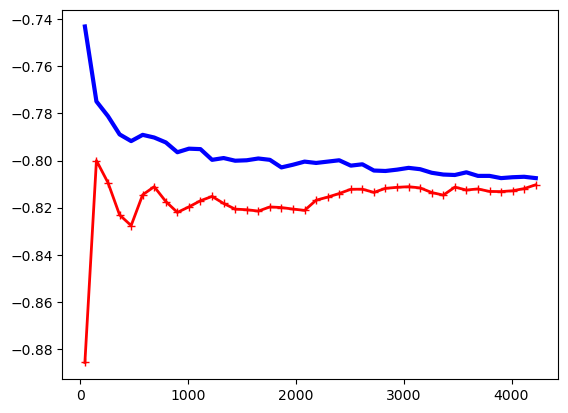

In [39]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, valid_scores = learning_curve(
model, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
scoring="accuracy")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

In [40]:
from sklearn.model_selection import cross_val_predict

In [41]:
y_pred = cross_val_predict(model, X, y, cv=kf)
y_proba = cross_val_predict(model, X, y, cv=kf, method="predict_proba")
y_pred_proba = y_proba[:, 1]

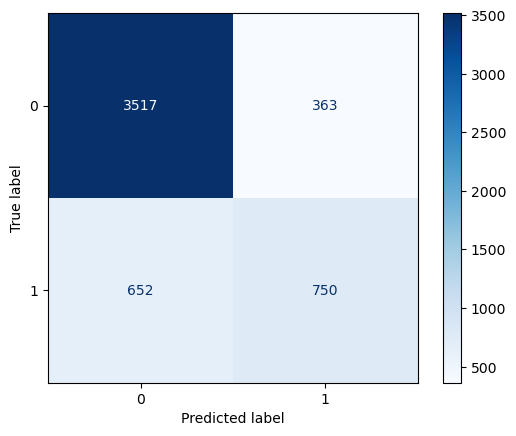

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [43]:
err=X.copy()
err['y_pred']=y_pred
err['y']=y
err['y_pred_proba']=y_pred_proba

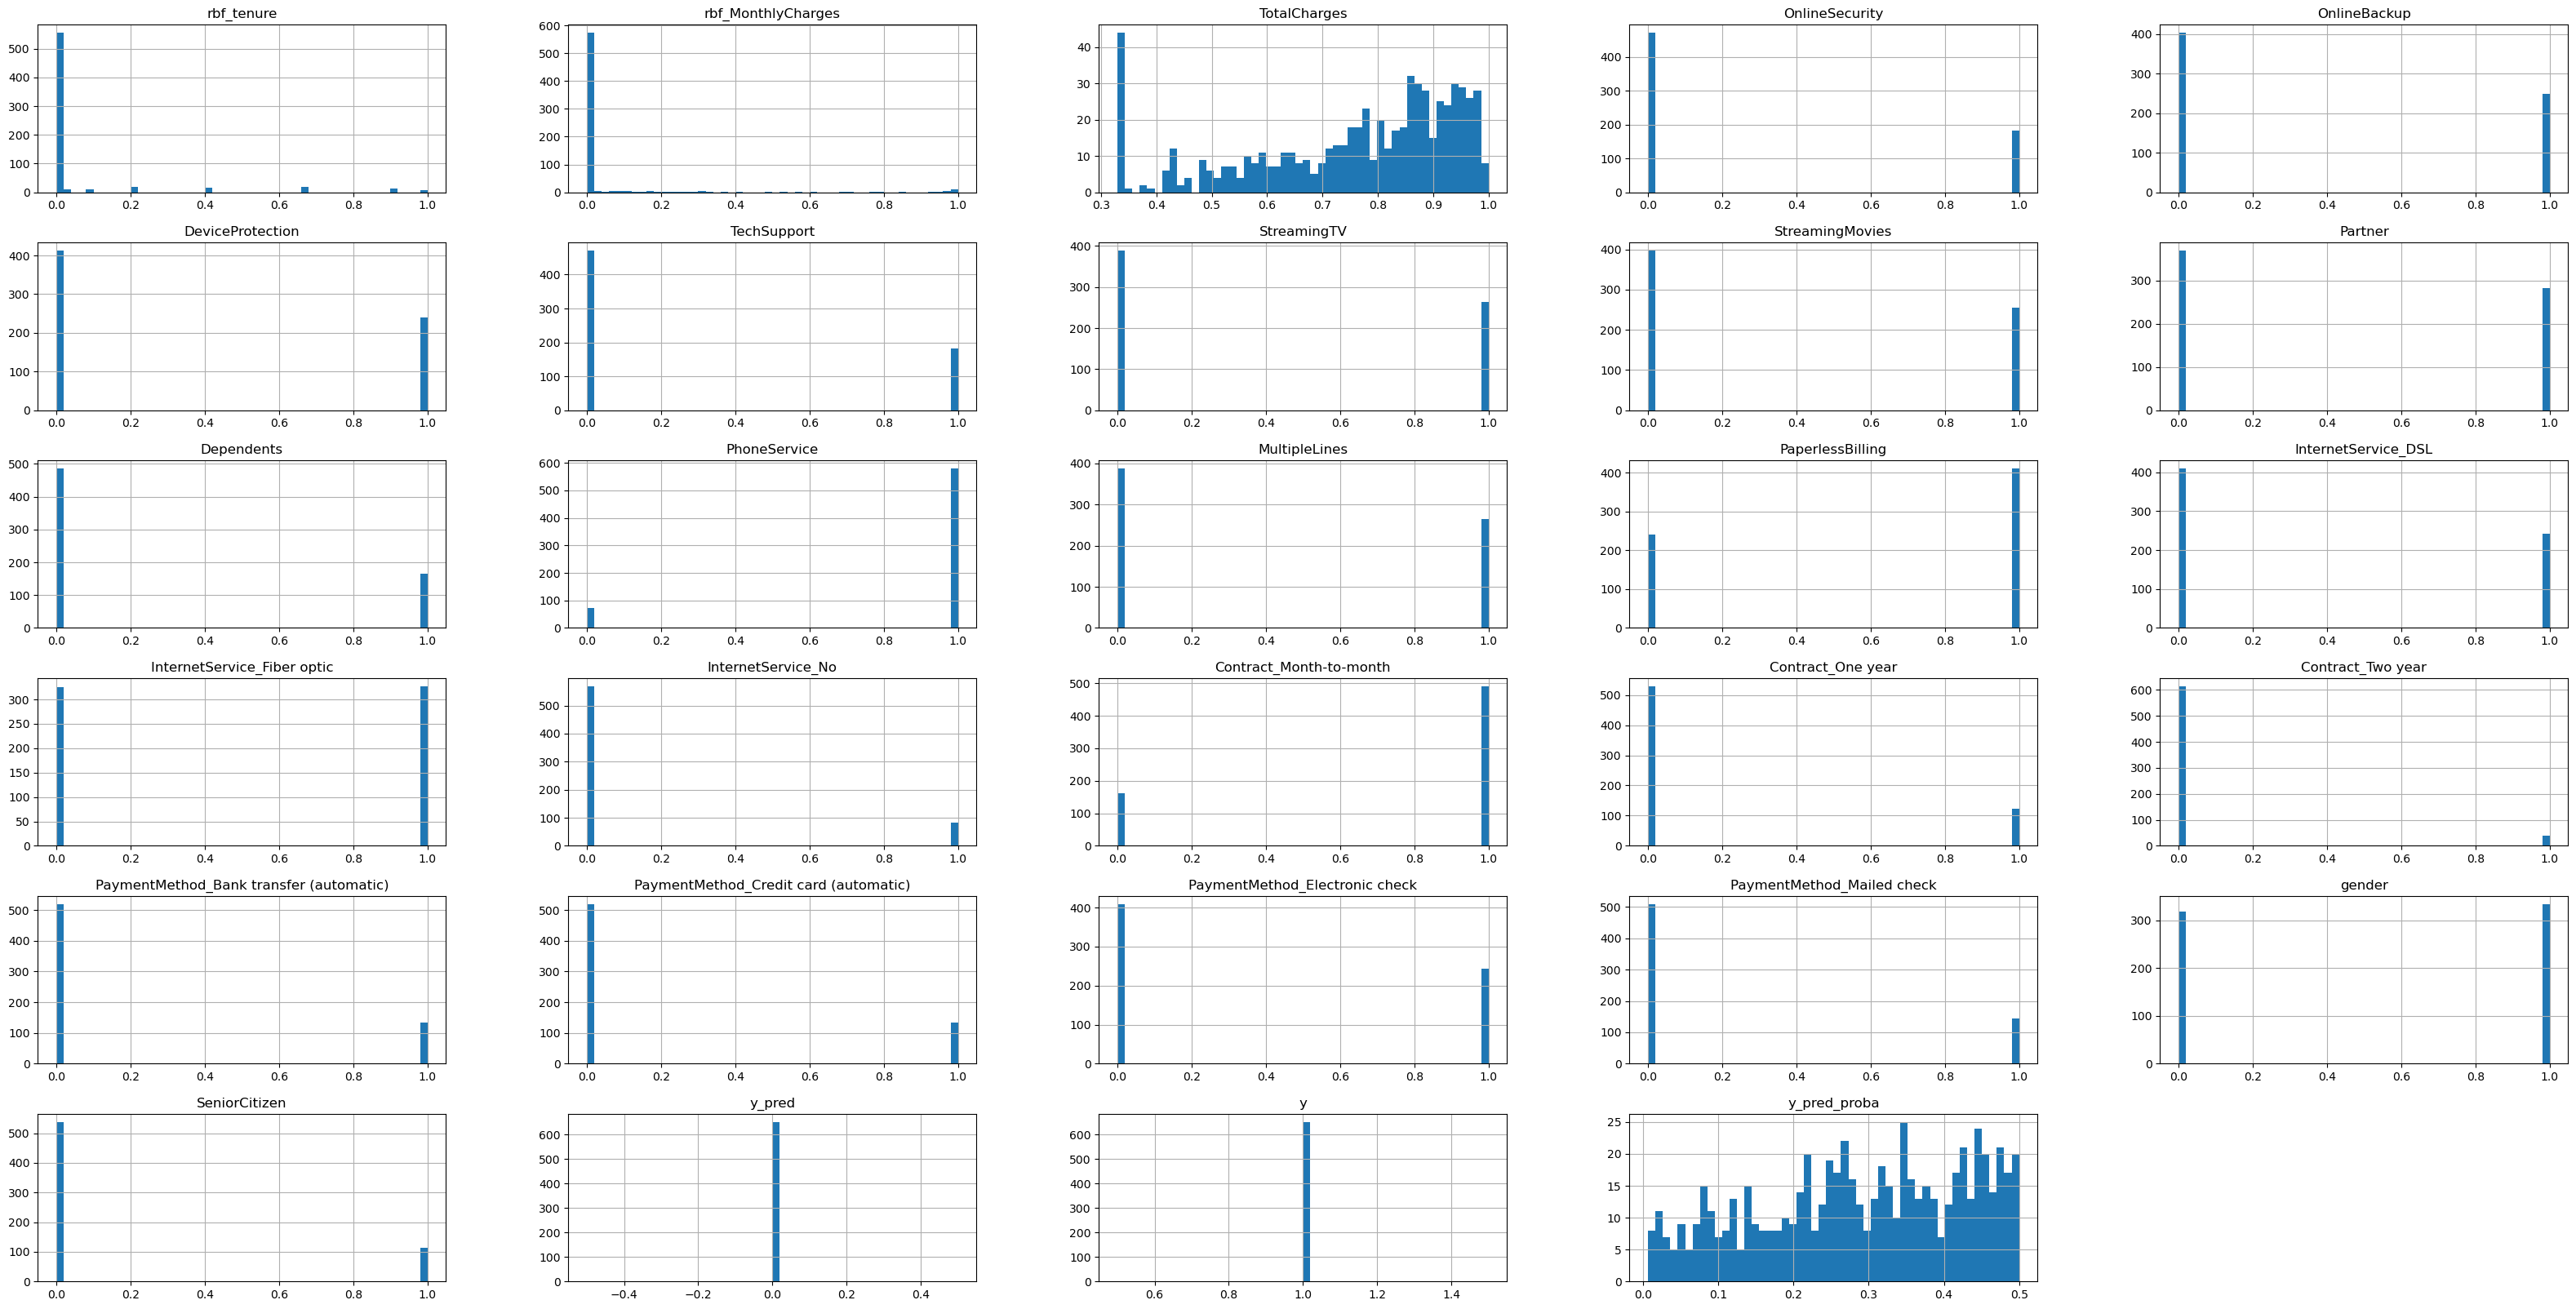

In [44]:
err[(err['y_pred']==0) & (err['y']==1) ].hist(bins=50,figsize=(40,20))
plt.show()

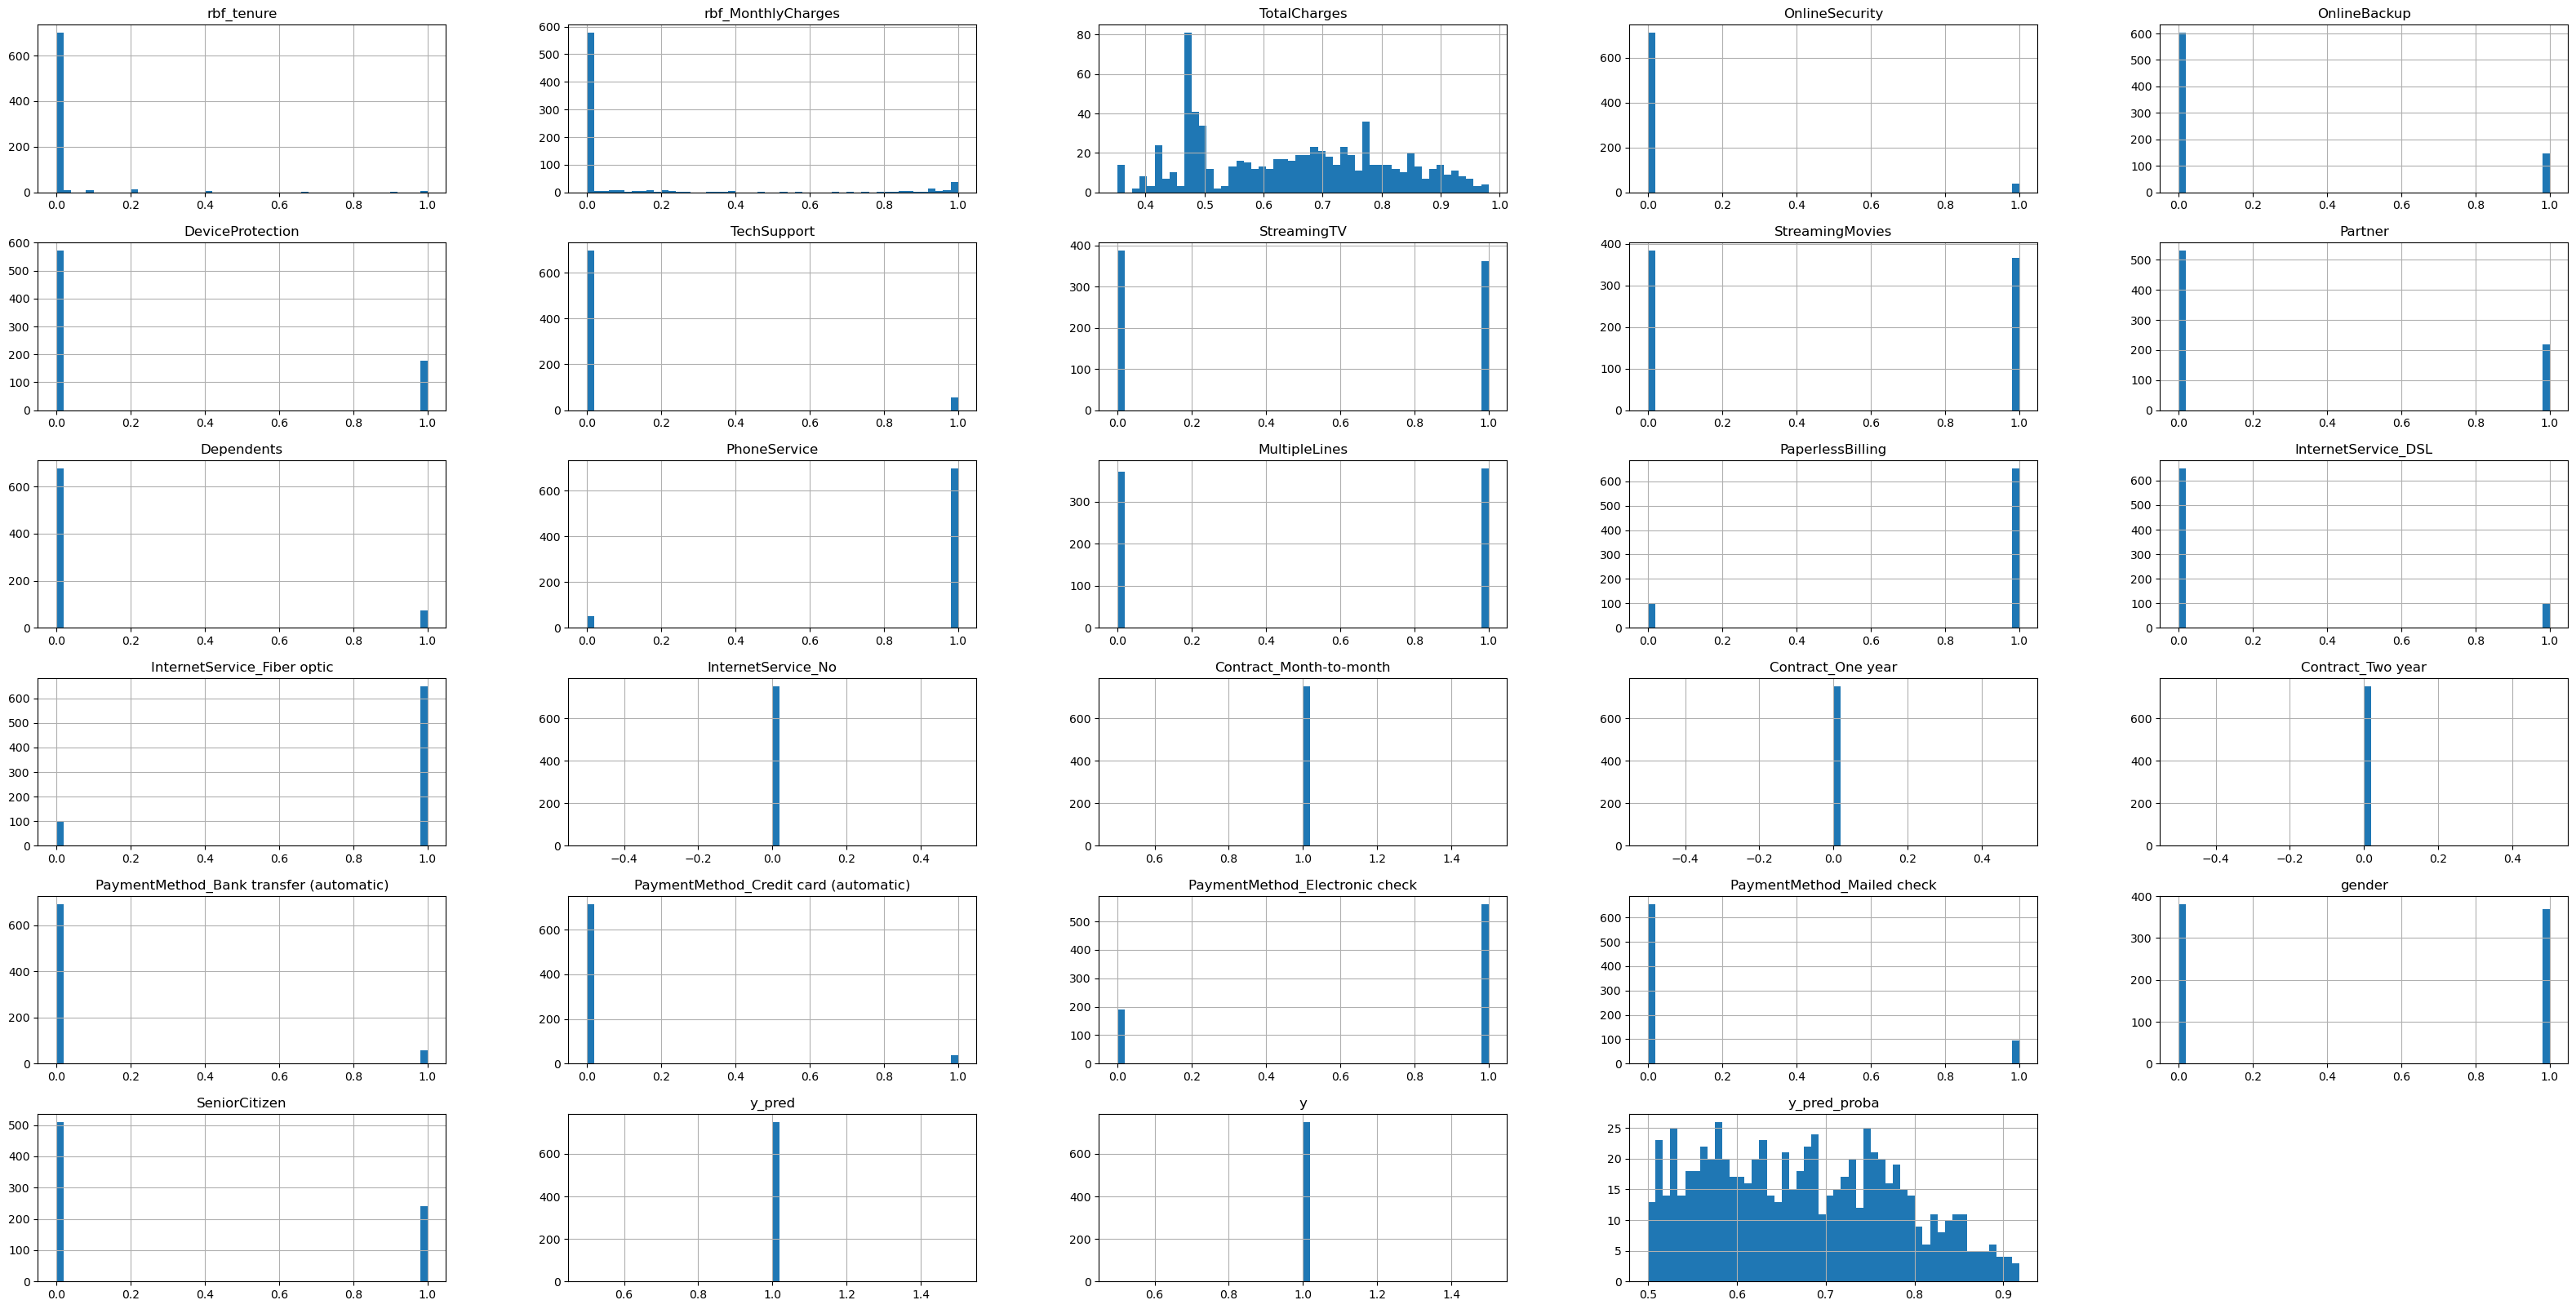

In [45]:
err[(err['y_pred']==1) & (err['y']==1) ].hist(bins=50,figsize=(40,20))
plt.show()

In [46]:
err[(err['y_pred']==0) & (err['y']==1) ].describe()

,rbf_tenure,rbf_MonthlyCharges,TotalCharges,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Partner,...,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,SeniorCitizen,y_pred,y,y_pred_proba
count,6.520000e+02,6.520000e+02,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,...,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.000000,652.0,652.0,652.000000
mean,6.799322e-02,5.365690e-02,0.757524,0.277607,0.381902,0.366564,0.277607,0.403374,0.391104,0.434049,...,0.058282,0.203988,0.203988,0.372699,0.219325,0.512270,0.174847,0.0,1.0,0.288454
std,2.075074e-01,1.932853e-01,0.188561,0.448162,0.486226,0.482236,0.448162,0.490951,0.488372,0.496012,...,0.234456,0.403269,0.403269,0.483894,0.414107,0.500233,0.380127,0.0,0.0,0.137755
min,0.000000e+00,1.374641e-116,0.329480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.006570
25%,2.187420e-32,1.919895e-54,0.638621,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.185079
50%,4.248354e-18,1.558350e-25,0.808863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,1.0,0.297795
75%,5.559513e-06,3.668152e-09,0.912825,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,1.0,0.413490
max,1.000000e+00,9.997500e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.0,0.499815


In [47]:
err[(err['y_pred']==1) & (err['y']==1) ].describe()

,rbf_tenure,rbf_MonthlyCharges,TotalCharges,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Partner,...,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,SeniorCitizen,y_pred,y,y_pred_proba
count,7.500000e+02,7.500000e+02,750.000000,750.000000,750.000000,750.000000,750.00000,750.000000,750.00000,750.000000,...,750.0,750.000000,750.000000,750.000000,750.000000,750.00000,750.000000,750.0,750.0,750.000000
mean,2.037848e-02,1.300640e-01,0.648146,0.052000,0.196000,0.237333,0.07200,0.482667,0.48800,0.292000,...,0.0,0.077333,0.048000,0.748000,0.126667,0.49200,0.320000,1.0,1.0,0.674296
std,1.109568e-01,3.031938e-01,0.159196,0.222175,0.397233,0.425732,0.25866,0.500033,0.50019,0.454986,...,0.0,0.267298,0.213909,0.434451,0.332821,0.50027,0.466787,0.0,0.0,0.105967
min,9.887752e-74,7.246394e-97,0.352462,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.0,1.0,0.500075
25%,8.939487e-35,1.715140e-29,0.487272,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.0,1.0,0.582638
50%,7.187782e-28,2.107205e-14,0.653920,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.0,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,1.0,1.0,0.672316
75%,8.489044e-15,7.764536e-04,0.774149,0.000000,0.000000,0.000000,0.00000,1.000000,1.00000,1.000000,...,0.0,0.000000,0.000000,1.000000,0.000000,1.00000,1.000000,1.0,1.0,0.755666
max,1.000000e+00,1.000000e+00,0.980845,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,...,0.0,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.0,1.0,0.917679


In [48]:
(err[(err['y_pred']==0) & (err['y']==1) ].mean()-err[(err['y_pred']==1) & (err['y']==1) ].mean()).sort_values()

y_pred                                    -1.000000
y_pred_proba                              -0.385842
PaymentMethod_Electronic check            -0.375301
InternetService_Fiber optic               -0.363800
Contract_Month-to-month                   -0.246933
PaperlessBilling                          -0.238965
SeniorCitizen                             -0.145153
MultipleLines                             -0.100425
StreamingMovies                           -0.096896
StreamingTV                               -0.079292
rbf_MonthlyCharges                        -0.076407
PhoneService                              -0.039763
y                                          0.000000
gender                                     0.020270
rbf_tenure                                 0.047615
Contract_Two year                          0.058282
PaymentMethod_Mailed check                 0.092658
TotalCharges                               0.109378
PaymentMethod_Bank transfer (automatic)    0.126654
InternetServ

In [49]:
print(len(err[(err['y']==1) & (err['InternetService_Fiber optic']==1)])/len(err[(err['y']==1)]))
print(len(err[(err['y']==0) & (err['InternetService_Fiber optic']==1)])/len(err[(err['y']==0)]))
print(len(err[(err['y']==0) & (err['InternetService_Fiber optic']==1)])/len(err[(err['InternetService_Fiber optic']==1)]))
print(len(err[(err['y']==1) & (err['InternetService_Fiber optic']==0)])/len(err[(err['InternetService_Fiber optic']==0)]))
print(len(err[(err['y']==1) & (err['InternetService_Fiber optic']==1)])/len(err[(err['InternetService_Fiber optic']==1)]))

0.6961483594864479
0.34716494845360824
0.5798536375376668
0.1439675566069618
0.42014636246233317


In [50]:
X1=X.copy()
X1['fib+mon']=((err['Contract_Month-to-month']==1) & (err['InternetService_Fiber optic']==1)).astype(int)

In [52]:
scores = cross_val_score(model, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.81456954 0.82497635 0.78977273 0.80208333 0.80871212]
Mean scores: 0.8080228132794358


In [53]:
model.fit(X1, y)
coeffs = pd.DataFrame({
    "Feature": X1.columns,
    "Coefficient": model.coef_[0]
})
print(coeffs.sort_values(by='Coefficient'))

                                    Feature  Coefficient
2                              TotalCharges    -4.429451
16                       InternetService_No    -1.037043
19                        Contract_Two year    -0.723249
0                                rbf_tenure    -0.445416
3                            OnlineSecurity    -0.366080
6                               TechSupport    -0.273120
10                               Dependents    -0.198015
1                        rbf_MonthlyCharges    -0.194019
4                              OnlineBackup    -0.176042
11                             PhoneService    -0.151985
9                                   Partner    -0.008885
24                                   gender     0.002703
21    PaymentMethod_Credit card (automatic)     0.019051
5                          DeviceProtection     0.025194
20  PaymentMethod_Bank transfer (automatic)     0.027145
23               PaymentMethod_Mailed check     0.086942
26                             

<Axes: >

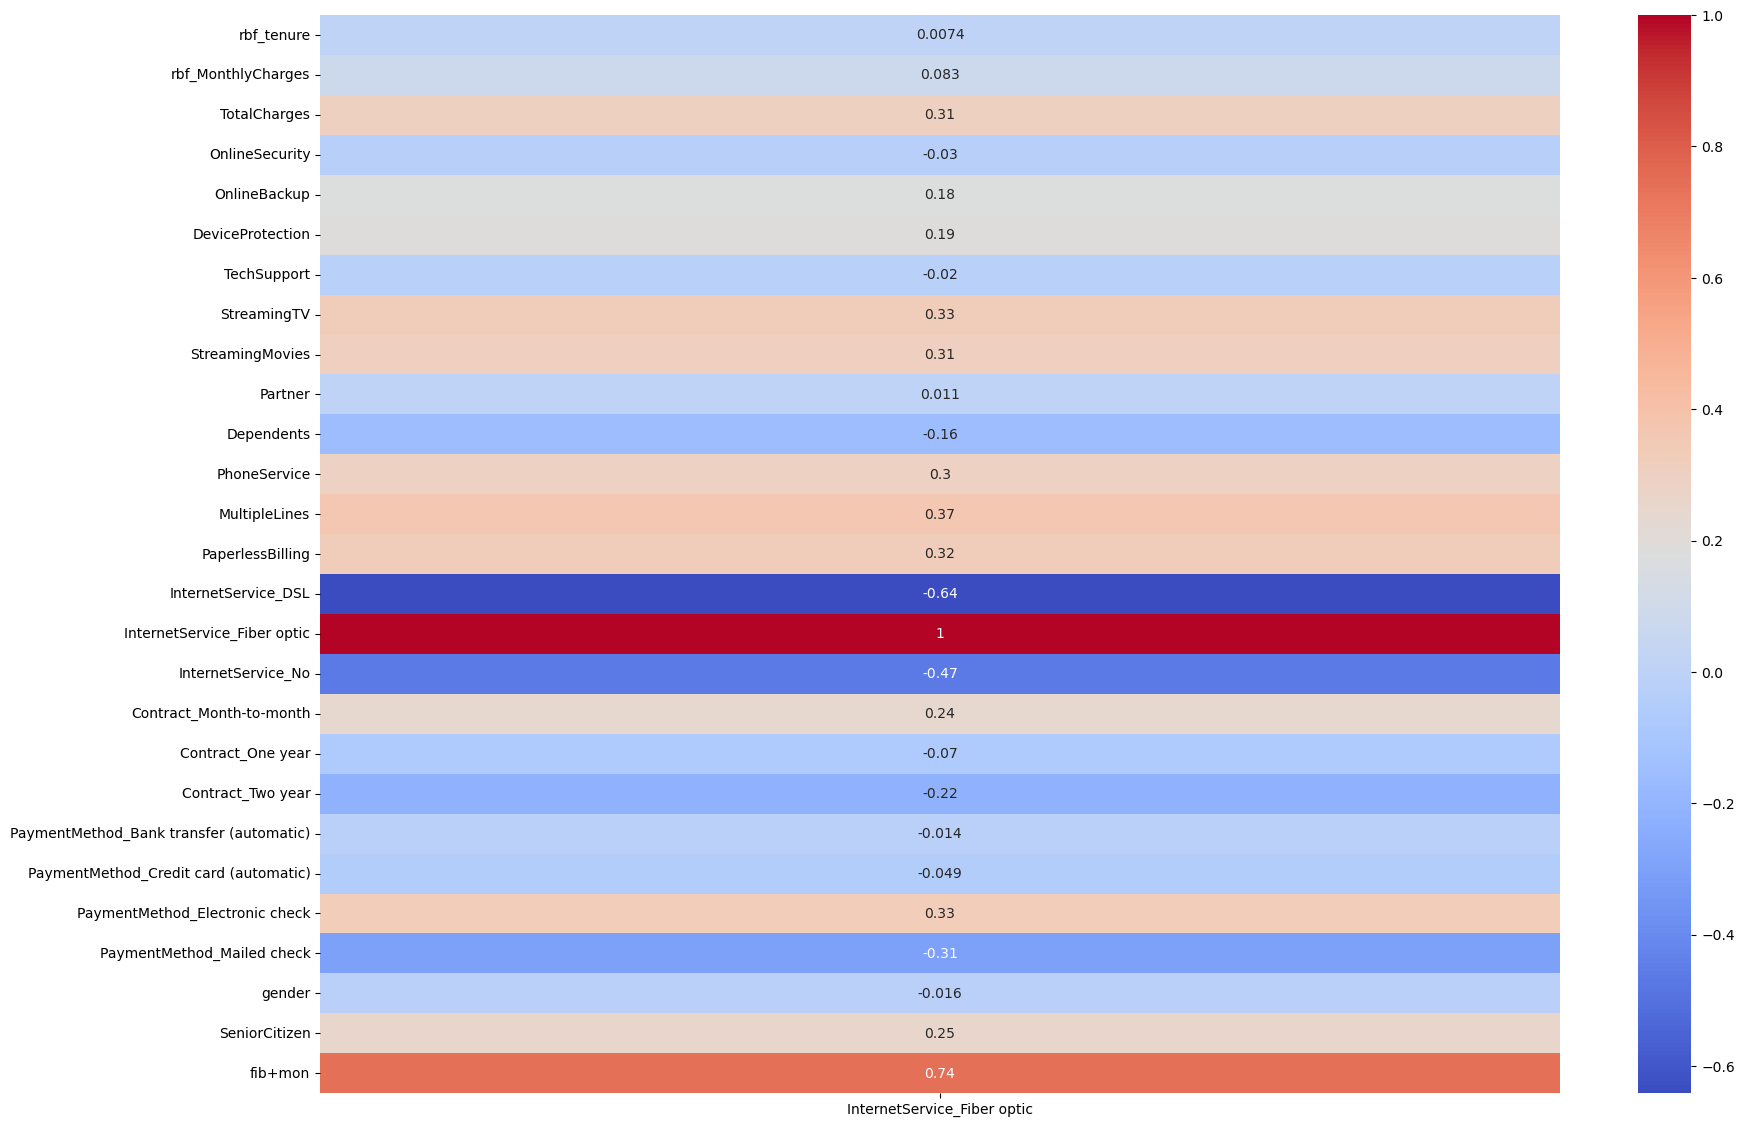

In [54]:
corr = X1.corr()[['InternetService_Fiber optic']]
plt.figure(figsize=(20,14))
sns.heatmap(corr, annot=True, cmap="coolwarm")

In [55]:
X1=X.copy()
X1['disc']=(processed_data['MonthlyCharges']*processed_data['tenure']-processed_data['TotalCharges']).values

In [56]:
X1['disc'].describe()

count    5282.000000
mean       -0.453067
std        67.389155
min      -373.250000
25%       -28.900000
50%         0.000000
75%        28.000000
max       370.850000
Name: disc, dtype: float64

In [57]:
X1['disc'] = min_max_scaler.fit_transform(X1[['disc']])

In [58]:
scores = cross_val_score(model, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.80983917 0.82119205 0.78787879 0.80113636 0.80871212]
Mean scores: 0.8057516986324934


In [59]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import loguniform
from sklearn.metrics import fbeta_score, make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)
param_distribs = {'C': loguniform(1e-5, 1e2),'penalty': ['l1', 'l2']}
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distribs,
    n_iter=50,          
    cv=5,               
    scoring=f2_scorer, 
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)

,estimator,LogisticRegre...r='liblinear')
,param_distributions,"{'C': <scipy.stats....00234D5183B60>, 'penalty': ['l1', 'l2']}"
,n_iter,50
,scoring,"make_scorer(f...dict', beta=2)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [60]:
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'C': np.float64(0.9047071957568393), 'penalty': 'l2'}
Best Score: 0.5612746755663811


In [61]:
model1 = LogisticRegression(solver='liblinear',class_weight='balanced')
scores = cross_val_score(model1, X, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.7615894  0.75212867 0.74905303 0.74147727 0.75094697]
Mean scores: 0.7510390685473467


In [62]:
y_pred1 = cross_val_predict(model1, X, y, cv=kf)
y_proba1 = cross_val_predict(model1, X, y, cv=kf, method="predict_proba")
y_pred_proba1 = y_proba1[:, 1]

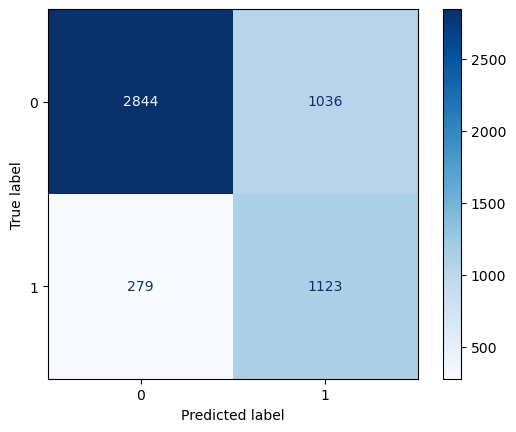

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [193]:
f2_scorer = make_scorer(fbeta_score, beta=2)
param_distribs = {'C': loguniform(1e-5, 1e2),'penalty': ['l1', 'l2']}
random_search = RandomizedSearchCV(
    estimator=model1,
    param_distributions=param_distribs,
    n_iter=50,          
    cv=5,               
    scoring=f2_scorer, 
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)

,estimator,LogisticRegre...r='liblinear')
,param_distributions,"{'C': <scipy.stats....00234E6D6B750>, 'penalty': ['l1', 'l2']}"
,n_iter,50
,scoring,"make_scorer(f...dict', beta=2)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [194]:
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'C': np.float64(1.0126313321124241e-05), 'penalty': 'l2'}
Best Score: 0.7374371842378957


## evaluation

In [64]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score

In [65]:
print(precision_score(y, y_pred))
print(recall_score(y, y_pred))

0.6738544474393531
0.5349500713266762


In [66]:
f1_score(y, y_pred) #we can ignore this we don't really care about the f1 score

0.5964214711729622

In [67]:
from sklearn.metrics import precision_recall_curve

In [68]:
precisions, recalls, thresholds = precision_recall_curve(y, y_pred_proba)

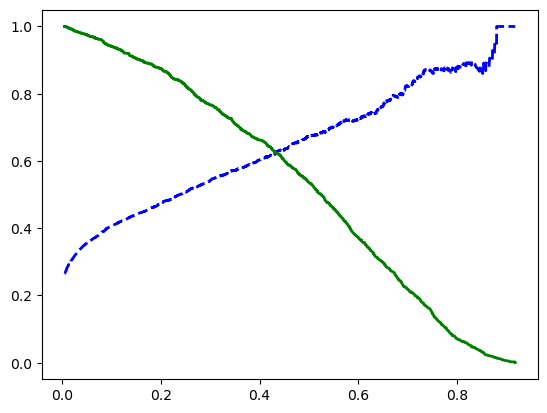

In [69]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.show()

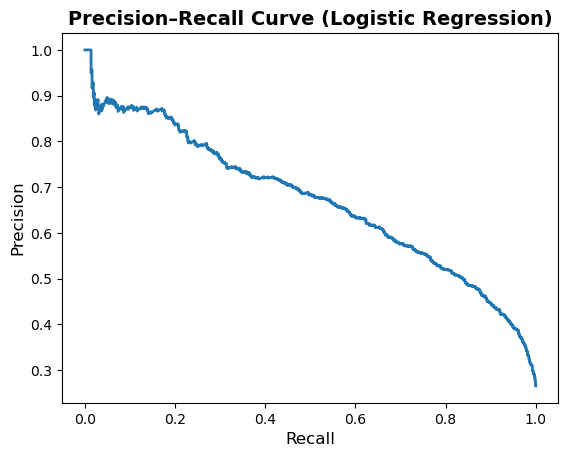

In [70]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision–Recall Curve (Logistic Regression)", fontsize=14, fontweight="bold")
plt.show()

In [71]:
idx_for_80_recall = (recalls <= 0.80).argmax()
threshold_for_80_recall = thresholds[idx_for_80_recall]
threshold_for_80_recall

np.float64(0.26752795046604316)

In [72]:
precisions[idx_for_80_recall]

np.float64(0.5199443413729128)

In [73]:
y_pred_new=(y_pred_proba>threshold_for_80_recall).astype(int)

In [74]:
from sklearn.metrics import accuracy_score
new_accuracy = accuracy_score(y, y_pred_new)
print(f"Overall CV Accuracy with custom threshold: {new_accuracy:.4f}")

Overall CV Accuracy with custom threshold: 0.7507


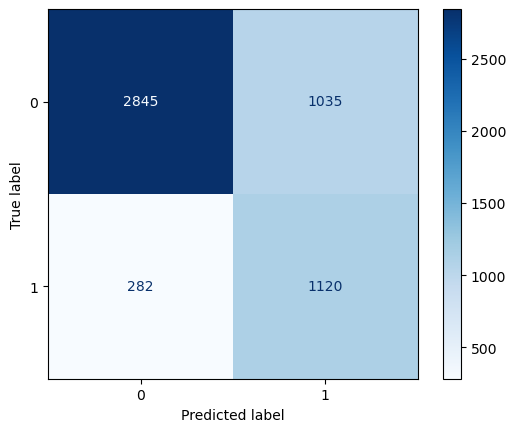

In [75]:
cm_new = confusion_matrix(y, y_pred_new)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_new)
disp.plot(cmap="Blues")
plt.show()

In [76]:
print(precision_score(y, y_pred_new))
print(recall_score(y, y_pred_new))

0.5197215777262181
0.7988587731811697


In [77]:
print(precision_score(y, y_pred1))
print(recall_score(y, y_pred1))

0.5201482167670217
0.8009985734664765


## Advanced models

In [78]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [80]:
scores = cross_val_score(tree_clf, X, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.7218543  0.72280038 0.74147727 0.73390152 0.72537879]
Mean scores: 0.729082451764571


In [81]:
y_predt = cross_val_predict(tree_clf, X, y, cv=kf)
y_probat = cross_val_predict(tree_clf, X, y, cv=kf, method="predict_proba")
y_pred_probat = y_probat[:, 1]

In [82]:
print(precision_score(y, y_predt))
print(recall_score(y, y_predt))

0.49014276002719237
0.514265335235378


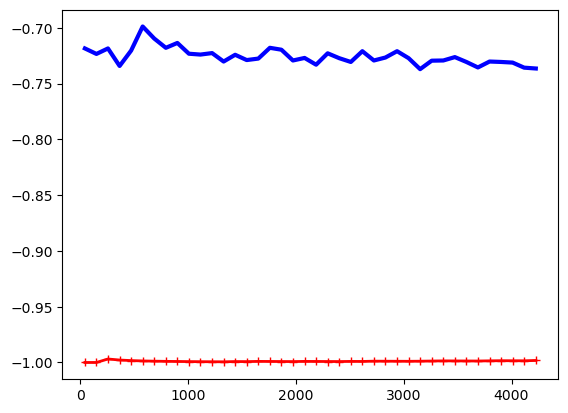

In [83]:
train_sizes, train_scores, valid_scores = learning_curve(
tree_clf, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
scoring="accuracy")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

In [84]:
param_distribs = {"max_depth": randint(2, 20), "min_samples_leaf": randint(1, 20) }
random_search = RandomizedSearchCV(
    estimator=tree_clf,
    param_distributions=param_distribs,
    n_iter=100,          
    cv=5,               
    scoring='accuracy', 
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)

,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....00234D7D5BA10>, 'min_samples_leaf': <scipy.stats....00234DDC55A90>}"
,n_iter,100
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [85]:
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1}
Best Score: 0.7907958487428686


In [86]:
tree_clf_n = DecisionTreeClassifier(random_state=42,max_depth=3,min_samples_leaf=1)
tree_clf_n.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


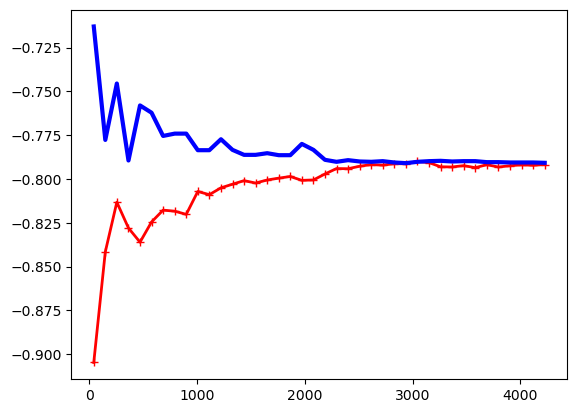

In [87]:
train_sizes, train_scores, valid_scores = learning_curve(
tree_clf_n, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
scoring="accuracy")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

In [88]:
y_predtn = cross_val_predict(tree_clf_n, X, y, cv=kf)
y_probatn = cross_val_predict(tree_clf_n, X, y, cv=kf, method="predict_proba")
y_pred_probatn = y_probatn[:, 1]

In [89]:
print(precision_score(y, y_predtn))
print(recall_score(y, y_predtn))

0.6873385012919897
0.37945791726105566


In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

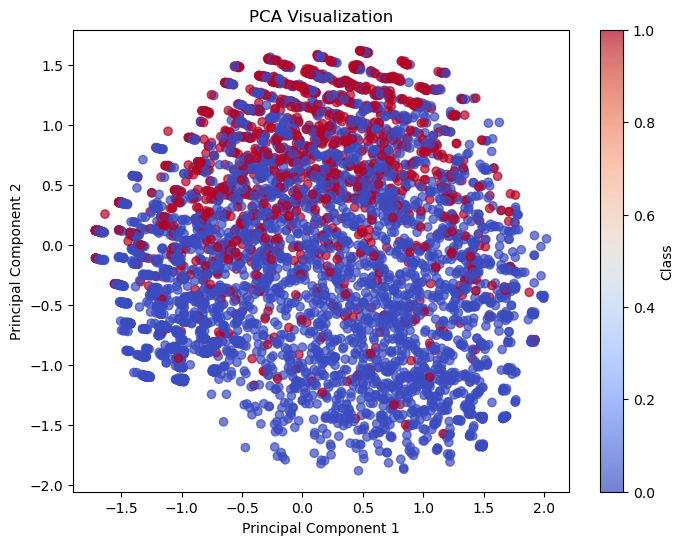

In [92]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.colorbar(label="Class")
plt.show()

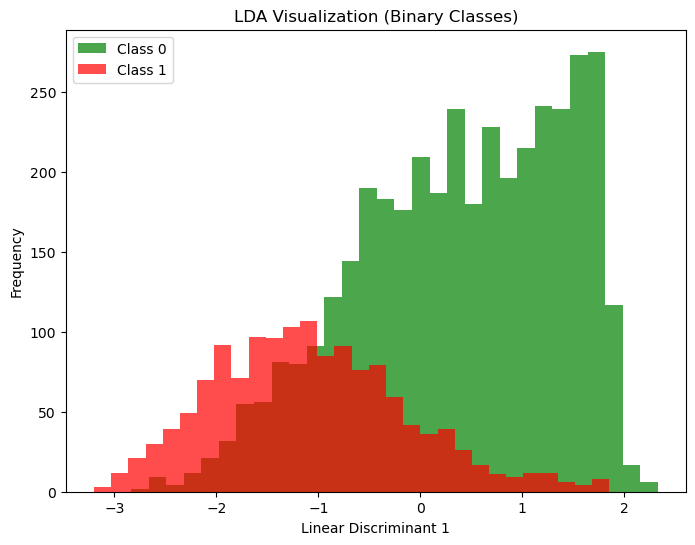

In [98]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)
plt.figure(figsize=(8,6))
plt.hist(X_lda[y==0], bins=30, alpha=0.7, label="Class 0", color="green")
plt.hist(X_lda[y==1], bins=30, alpha=0.7, label="Class 1", color="red")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Frequency")
plt.title("LDA Visualization (Binary Classes)")
plt.legend()
plt.show()

In [101]:
random_search.fit(X_lda, y)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 15}
Best Score: 0.8051829792723832


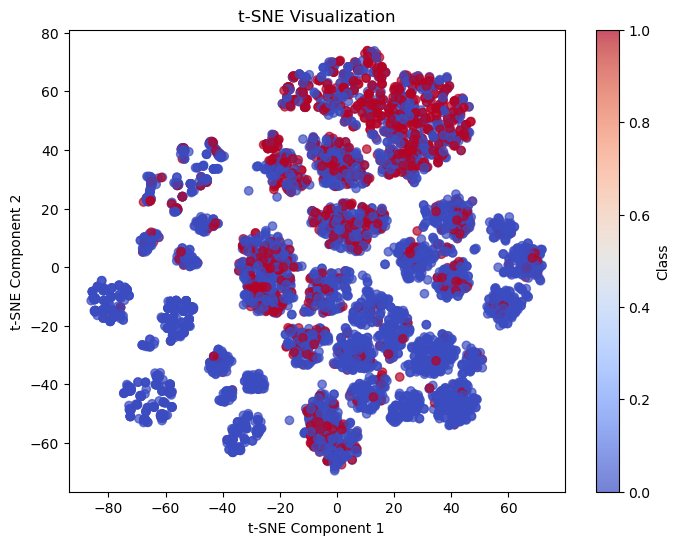

In [99]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization")
plt.colorbar(label="Class")
plt.show()

## Let's try forests, ensambles and bosstings

In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [120]:
rnd_clf = RandomForestClassifier(n_jobs=-1, random_state=42)
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 5, 8], 
    "min_samples_leaf": [20, 50, 100], 
    "max_features": ["sqrt", 0.5] 
}
grid_search = GridSearchCV(
    rnd_clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X, y)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [20, 50, ...], 'n_estimators': [300, 500]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [121]:
print("Best parameters:", grid_search.best_params_)
print("Best estimator:", grid_search.best_score_)

Best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 500}
Best estimator: 0.8012066024483243


In [125]:
rnd_clf_n = RandomForestClassifier(n_jobs=-1, random_state=42,max_leaf_nodes=64,n_estimators=300)
rnd_clf_n.fit(X,y)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,64
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [116]:
y_predr = cross_val_predict(rnd_clf_n, X, y, cv=kf)
y_probar = cross_val_predict(rnd_clf_n, X, y, cv=kf, method="predict_proba")
y_pred_probar = y_probar[:, 1]

In [117]:
print(precision_score(y, y_predr))
print(recall_score(y, y_predr))

0.666023166023166
0.4921540656205421


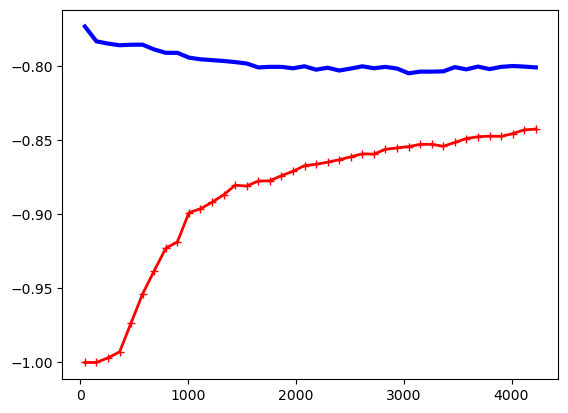

In [118]:
train_sizes, train_scores, valid_scores = learning_curve(
rnd_clf_n, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
scoring="accuracy")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

In [122]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
svm_clf = LinearSVC(C=1, random_state=42)
scores = cross_val_score(svm_clf, X, y, cv=5, scoring="accuracy")
print("Accuracy scores for each fold:", scores)
print("Mean accuracy:", scores.mean())

Accuracy scores for each fold: [0.80321665 0.8230842  0.80587121 0.78030303 0.80587121]
Mean accuracy: 0.8036692612023737


In [126]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(
    rnd_clf_n, X, y, n_repeats=10, random_state=42, scoring='recall')

In [139]:
feature_names = X.columns
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std_Dev': perm_importance.importances_std
}).sort_values(by='Importance', ascending=False)

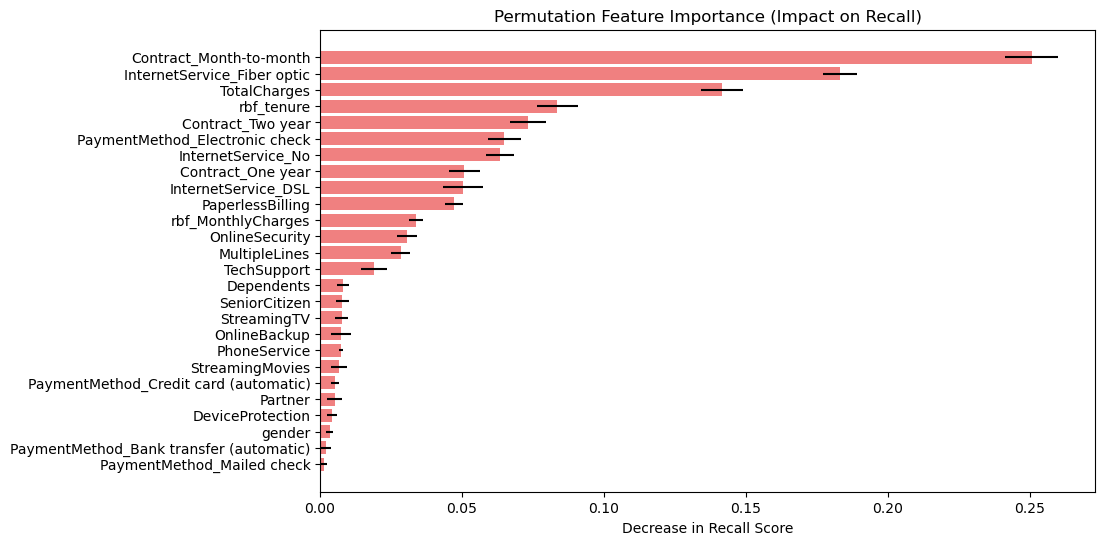

In [140]:
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], xerr=perm_importance_df['Std_Dev'], color='lightcoral')
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (Impact on Recall)")
plt.xlabel("Decrease in Recall Score")
plt.show()

In [171]:
X1=X.copy()
X1['fib+mon']=((err['Contract_Month-to-month']==1) & (err['InternetService_Fiber optic']==1)).astype(int)

In [167]:
scores = cross_val_score(rnd_clf_n, X1, y, cv=5, scoring="accuracy")
print("Accuracy scores for each fold:", scores)
print("Mean accuracy:", scores.mean())

Accuracy scores for each fold: [0.79943236 0.82497635 0.78598485 0.78219697 0.80113636]
Mean accuracy: 0.798745377139417


In [176]:
X.groupby('InternetService_Fiber optic')['TotalCharges'].mean()

InternetService_Fiber optic
0.0    0.717374
1.0    0.824051
Name: TotalCharges, dtype: float64

In [172]:
X1['hig_fib']=X1['fib+mon']*X1['TotalCharges']

In [169]:
scores = cross_val_score(model, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.81456954 0.82497635 0.78977273 0.80208333 0.80871212]
Mean scores: 0.8080228132794358


In [173]:
X1.drop('hig_fib', axis=1, inplace=True)

In [174]:
X1.drop('fib+mon', axis=1, inplace=True)

In [177]:
X.groupby('InternetService_Fiber optic')['rbf_MonthlyCharges'].mean()

InternetService_Fiber optic
0.0    0.051288
1.0    0.087955
Name: rbf_MonthlyCharges, dtype: float64

In [178]:
X1.drop('TotalCharges', axis=1, inplace=True)

In [180]:
scores = cross_val_score(model, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.80889309 0.79470199 0.76704545 0.78598485 0.79640152]
Mean scores: 0.7906053797196182


In [181]:
scores = cross_val_score(rnd_clf_n, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.80794702 0.80321665 0.76609848 0.78977273 0.78693182]
Mean scores: 0.79079334021387


In [183]:
median_cost = X1['rbf_MonthlyCharges'].median()
X1['is_expensive_fiber'] = ((X1['InternetService_Fiber optic'] == 1.0) & (X1['rbf_MonthlyCharges'] > median_cost)).astype(int)

In [184]:
scores = cross_val_score(model, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.80605487 0.80227058 0.76325758 0.7907197  0.79450758]
Mean scores: 0.7913620595739801


In [185]:
scores = cross_val_score(rnd_clf_n, X1, y, cv=kf, scoring="accuracy")
print("scores:", scores)
print("Mean scores:", scores.mean())

scores: [0.80700095 0.8051088  0.76704545 0.78977273 0.78598485]
Mean scores: 0.7909825549726213


In [186]:
X1.drop('is_expensive_fiber', axis=1, inplace=True)

In [188]:
rnd_clf_n.fit(X1,y)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,64
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [189]:
perm_importance = permutation_importance(
    rnd_clf_n, X1, y, n_repeats=10, random_state=42, scoring='recall')

In [190]:
feature_names = X1.columns
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std_Dev': perm_importance.importances_std
}).sort_values(by='Importance', ascending=False)

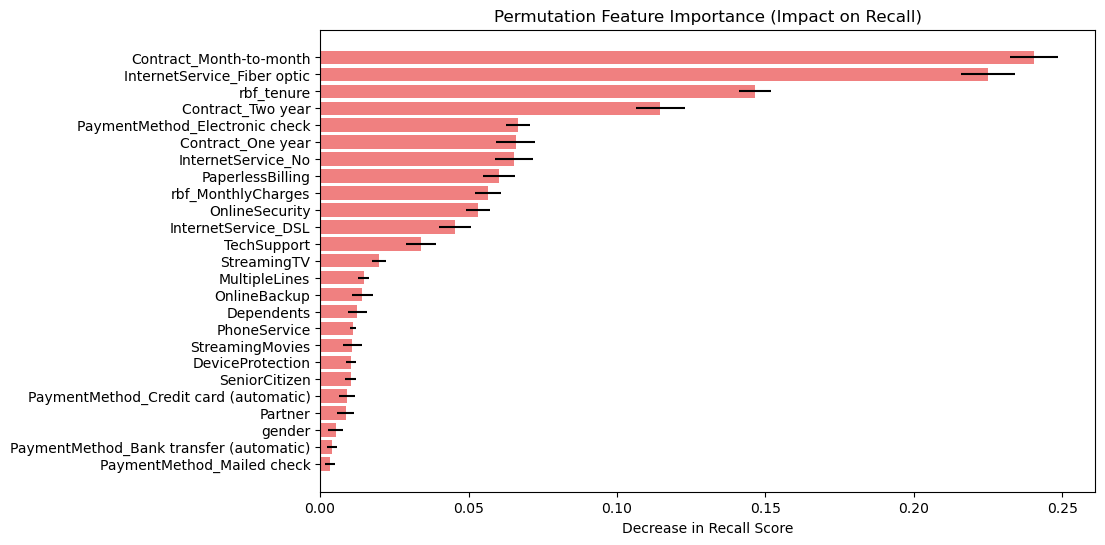

In [191]:
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], xerr=perm_importance_df['Std_Dev'], color='lightcoral')
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (Impact on Recall)")
plt.xlabel("Decrease in Recall Score")
plt.show()

## Wrapping things up and CONCLUSIONS

### the conclusions are-
the data is linear that is why my best performin model was linear regression <br>
the useful thing I got is I should drop total charges <br>
my application is to predict ppl who will leave rather than just have high accuracy<br>
hence i fine tuned my model for that <br>
i traded precission for more recall <br>
the analysis of the data is that there is high overlap between both the classes and there isn't any strong feature tat reveals the full information

In [195]:
preprocessing = ColumnTransformer([("yes_to_1", yes_no_transformer, bin_at),("ohe", enc, ohe_at),('drop','drop',['TotalCharges']),('ohe_gen',gender_transformer,['gender'])],remainder='passthrough',verbose_feature_names_out=False)
preprocessing.set_output(transform="pandas")

,transformers,"[('yes_to_1', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,func,<function tru...00234D4F67B00>
,inverse_func,None
,validate,False


In [197]:
rb_col=['MonthlyCharges','tenure']
ftr_trs = ColumnTransformer([("rbf_kernel", MedianRBFTransformer(gamma=0.1), rb_col)],remainder='passthrough',verbose_feature_names_out=False)
ftr_trs.set_output(transform="pandas")

,transformers,"[('rbf_kernel', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,gamma,0.1


In [198]:
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
ftr_scl = ColumnTransformer([("scale_data", min_max_scaler, ['rbf_tenure','rbf_MonthlyCharges',])],remainder='passthrough',verbose_feature_names_out=False)
ftr_scl.set_output(transform="pandas")

,transformers,"[('scale_data', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [199]:
master_preprocessor = Pipeline(steps=[
    ('step1_process', preprocessing),     
    ('step2_transform', ftr_trs), 
    ('step3_scale', ftr_scl)           
])
master_preprocessor.set_output(transform="pandas")

,steps,"[('step1_process', ...), ('step2_transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('yes_to_1', ...), ('ohe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [221]:
testing=X_train.copy()

In [207]:
training_transformed = master_preprocessor.fit_transform(training)

In [208]:
training_transformed

,rbf_tenure,rbf_MonthlyCharges,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Partner,Dependents,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,customerID,SeniorCitizen
6661,0.000000e+00,4.670921e-13,0,1,0,1,1,1,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,3704-IEAXF,0
4811,7.187782e-28,8.540312e-27,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,5175-AOBHI,0
2193,2.187420e-32,2.787151e-106,0,0,0,0,0,0,0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,6922-NCEDI,0
1904,2.187420e-32,1.226761e-25,0,1,0,1,0,1,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,3143-ILDAL,0
6667,4.248354e-18,2.773445e-04,0,0,0,0,0,1,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0872-NXJYS,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4250,6.245366e-51,6.245366e-51,1,1,1,1,1,0,0,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0565-JUPYD,0
1488,8.939487e-35,8.066314e-17,1,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,8695-WDYEA,0
6303,2.456773e-77,6.137185e-66,0,1,1,1,1,1,1,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,6308-CQRBU,0
2710,8.208500e-02,9.809588e-110,0,0,0,0,0,0,1,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,3594-BDSOA,0


In [222]:
model1.fit(X1,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [210]:
from sklearn.base import ClassifierMixin

In [217]:
class PredictAndAppendID(BaseEstimator, ClassifierMixin):
    def __init__(self, model, id_col='customerID'):
        self.model = model
        self.id_col = id_col
        self.is_fitted_ = True
        
    def fit(self, X, y=None):
        X_clean = X.drop(columns=[self.id_col])
        self.model.fit(X_clean, y)
        return self
        
    def predict(self, X):
        saved_ids = X[self.id_col].reset_index(drop=True)
        
        X_clean = X.drop(columns=[self.id_col])
        
        preds = self.model.predict(X_clean)
        
        return pd.DataFrame({
            self.id_col: saved_ids,
            'prediction': preds
        })

In [218]:
wrapper = PredictAndAppendID(model=model1, id_col='customerID')

final_pipeline = Pipeline(steps=[
    ('process', master_preprocessor),     
    ('predict', wrapper)            
])

In [223]:
final_results = final_pipeline.predict(testing)
print(final_results)

      customerID  prediction
0     3704-IEAXF           0
1     5175-AOBHI           1
2     6922-NCEDI           0
3     3143-ILDAL           1
4     0872-NXJYS           1
...          ...         ...
5277  0565-JUPYD           0
5278  8695-WDYEA           0
5279  6308-CQRBU           0
5280  3594-BDSOA           0
5281  6490-FGZAT           0

[5282 rows x 2 columns]


In [229]:
y_test['Churn']=(y_test['Churn']=='Yes').astype(int)

In [230]:
y_test

,Churn,customerID
5909,0,5343-SGUBI
3670,0,5442-BXVND
6220,0,6434-TTGJP
5905,0,1628-BIZYP
6435,0,0298-XACET
...,...,...
476,0,3780-DDGSE
1607,1,4154-AQUGT
6808,0,1116-DXXDF
2962,1,3237-AJGEH


In [231]:
final_results = final_pipeline.predict(X_test)
print(final_results)

      customerID  prediction
0     5343-SGUBI           0
1     5442-BXVND           0
2     6434-TTGJP           0
3     1628-BIZYP           1
4     0298-XACET           0
...          ...         ...
1756  3780-DDGSE           1
1757  4154-AQUGT           1
1758  1116-DXXDF           0
1759  3237-AJGEH           1
1760  6704-UTUKK           1

[1761 rows x 2 columns]


In [232]:
print(precision_score(y_test['Churn'], final_results['prediction']))
print(recall_score(y_test['Churn'], final_results['prediction']))

0.489247311827957
0.7794432548179872


## so my model has more than 75% reccall rate with nearly 50% precission

# The END